10.10.2025:  
Purpose: create merged navigation data from eelys 6DOF
Below is all straight copy paste from path:  
C:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\postprocess_uhi\mjosa_database\correct_navigation_data\create_csv_from_log_2.ipynb

border color: red


-------------------------------------------------------------------

conitnuation from dev6. it just got so messy since copilot started doing stuff


want to create the functions needed for create_csv_from_log

# fix plot function

start by talking in functions already created

In [1]:
import sys
import os

sys.path.append(os.path.abspath("../../georef/eely_log_plot"))

from Eelume import PyPost as pp
import matplotlib.pyplot as plt
import datetime as datetime
import os
import numpy as np

sys.path.append(os.path.abspath("../../georef"))

from utils.analyze_log_file import LogData

plt.rcParams["figure.figsize"] = (3, 2)

import types

%matplotlib inline

In [2]:
filename = r"E:\mjosa\29\log_files\LOG_2024-10-29_10-13-32.db3"
db = pp.DatabaseHandler(filename)

start_time = datetime.datetime(2024, 10, 29, 10, 10, 00, tzinfo=datetime.timezone.utc)
end_time = datetime.datetime(2024, 10, 29, 13, 15, 00, tzinfo=datetime.timezone.utc)

# time comments:
# 10:10 we start to move, so good place to start
# 13:15 we start to assend, so can stop here

analyzer = pp.MotionAnalyzer(db, start_time=start_time, end_time=end_time)
csv_file_path = r"E:\mjosa_new\navigation_data\nav_data_from_logfile.csv"

In [3]:
# stop run all

In [4]:
main_csv = r"E:\mjosa_new\navigation_data\nav_data_from_logfile.csv"
log_data = LogData(main_csv)

# 2. Define Lake Mjøsa origin in degrees
origin_deg = (60.8011575, 10.7122345)

In [5]:
analyzer.create_aligned_csv_file(csv_file_path)

Creating time-aligned CSV...
Common time range: 1730196822.8 to 1730207699.9
Reference time grid: 232682 points
  ⚠️  altitude [m]: 12 NaN values (0.0%)
Removed 12 rows with NaN values
Final dataset: 232670 rows
✅ Saved aligned CSV to: E:\mjosa_new\navigation_data\nav_data_from_logfile.csv


,timestamp [unix epoch s],latitude [deg],longitude [deg],depth [m],roll [deg],pitch [deg],yaw [deg],altitude [m]
0,1.730197e+09,60.801109,10.705259,110.788911,-1.675687,-10.001676,295.246290,11.499957
1,1.730197e+09,60.801109,10.705259,110.788917,-1.685247,-10.020624,295.241885,11.501132
2,1.730197e+09,60.801109,10.705259,110.794405,-1.696334,-10.042600,295.236776,11.502495
3,1.730197e+09,60.801109,10.705259,110.798876,-1.704558,-10.061631,295.231732,11.503605
4,1.730197e+09,60.801109,10.705259,110.798878,-1.713900,-10.083250,295.226002,11.504867
...,...,...,...,...,...,...,...,...
232665,1.730208e+09,60.800311,10.706544,98.432998,-0.475657,-1.878903,179.292972,10.713712
232666,1.730208e+09,60.800311,10.706544,98.425704,-0.530112,-1.875640,179.303664,10.724517
232667,1.730208e+09,60.800311,10.706544,98.420513,-0.549821,-1.874459,179.307534,10.728428
232668,1.730208e+09,60.800311,10.706544,98.405813,-0.585707,-1.858854,179.308112,10.739503


In [6]:
# Monkey patch the LogData class


def plot_combined(self, use_meters=False, origin=None):
    """
    Generates complete diagnostic plots:
    1) Position scatter
    2) Pose time series (lat, lon, depth, roll, pitch, yaw)
    3) Altitude time series
    4) 3D trajectory with depth (positive down)

    Parameters:
    -----------
    use_meters : bool, optional
        If True, converts lat/lon to meters.
        If False (default), uses degrees.
    origin : tuple(lat, lon), optional
        Reference point for meter conversion. Required if use_meters=True.
    """
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    import numpy as np

    # Convert spatial coords
    if use_meters:
        if origin is None:
            raise ValueError("origin must be provided when use_meters=True")
        east, north = self.deg_to_meter_simple(
            self.latitude, self.longitude, origin=origin
        )
        x_coords, y_coords = east, north
        x_label, y_label = "East [m]", "North [m]"
        x3_label, y3_label = "North [m]", "East [m]"  # swapped for 3D
    else:
        x_coords, y_coords = self.longitude, self.latitude
        x_label, y_label = "Lon [deg]", "Lat [deg]"
        x3_label, y3_label = "Lat [deg]", "Lon [deg]"  # swapped for 3D

    # 1. Position scatter
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(x_coords, y_coords, s=5, alpha=0.7)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title("Position")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

    # 2. Pose time series
    signals = [
        ("latitude", "Lat [deg]"),
        ("longitude", "Lon [deg]"),
        ("depth", "Depth [m]"),
        ("roll", "Roll [deg]"),
        ("pitch", "Pitch [deg]"),
        ("yaw", "Yaw [deg]"),
    ]
    for attr, label in signals:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.plot(self.timestamp, getattr(self, attr), color="k")
        ax.set_xlabel("Time [s] UTC")
        ax.set_ylabel(label)
        ax.set_title(f"{label} over Time")
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        plt.show()

    # 3. Altitude time series
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(self.timestamp, self.altitude, color="g")
    ax.set_xlabel("Time [s] UTC")
    ax.set_ylabel("Alt [m]")
    ax.set_title("Altitude over Time")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

    # 4. 3D trajectory with proper axis orientation
    # Ensure all arrays have same length
    min_length = min(len(y_coords), len(x_coords), len(self.depth))
    x3_data = y_coords[:min_length]  # north for x-axis
    y3_data = x_coords[:min_length]  # east for y-axis
    depth_data = self.depth[:min_length]

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot(x3_data, y3_data, depth_data, color="b")
    ax.set_xlabel(x3_label)
    ax.set_ylabel(y3_label)
    ax.set_zlabel("Depth [m]")
    ax.invert_zaxis()  # 0 at top, positive down
    ax.invert_yaxis()
    ax.set_title("3D Trajectory")

    # Debug info
    print(f"3D Plot: {len(x3_data)} points")
    print(f"X-axis range: {x3_data.min():.6f} to {x3_data.max():.6f}")
    print(f"Y-axis range: {y3_data.min():.6f} to {y3_data.max():.6f}")
    print(f"Depth range: {depth_data.min():.2f} to {depth_data.max():.2f}")

    fig.tight_layout()
    plt.show()


# Apply monkey patch
LogData.plot_combined = plot_combined


def deg_to_meter_simple(self, latitudes, longitudes, origin=None):
    """
    Convert lat/lon → metres.
    If `origin` is None, the first sample is used.
    Otherwise give (lat0, lon0) as a tuple.
    """
    import numpy as np

    lat0, lon0 = (latitudes[0], longitudes[0]) if origin is None else origin
    R = 6_378_137.0  # WGS-84 equatorial radius [m]

    lat_rad = np.radians(latitudes)
    lon_rad = np.radians(longitudes)
    lat0_rad = np.radians(lat0)
    lon0_rad = np.radians(lon0)

    east = (lon_rad - lon0_rad) * R * np.cos(lat0_rad)
    north = (lat_rad - lat0_rad) * R
    return east, north


LogData.deg_to_meter_simple = deg_to_meter_simple

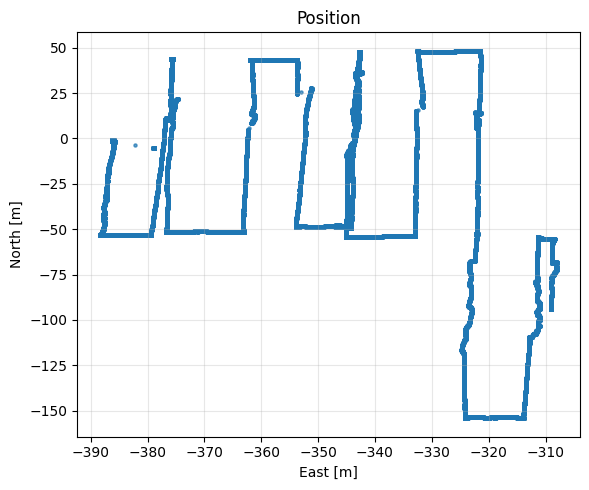

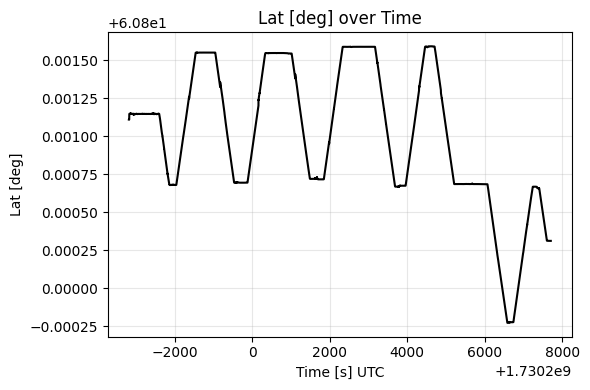

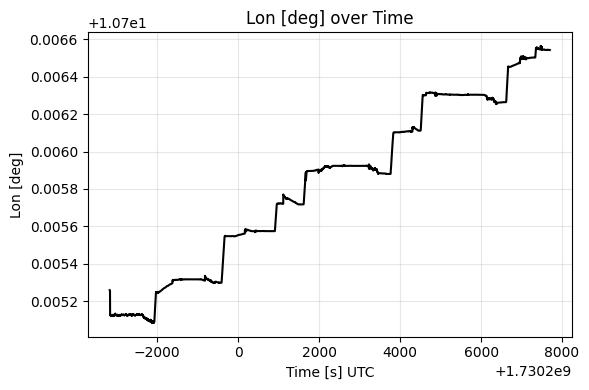

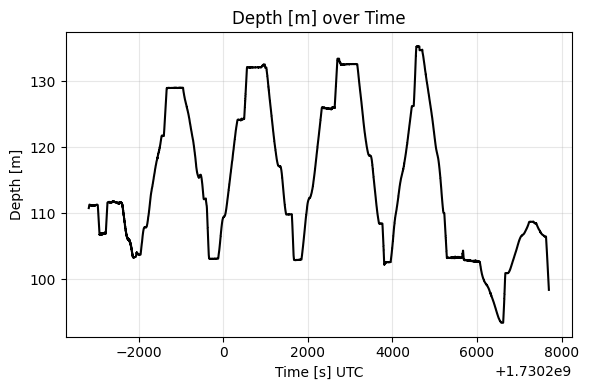

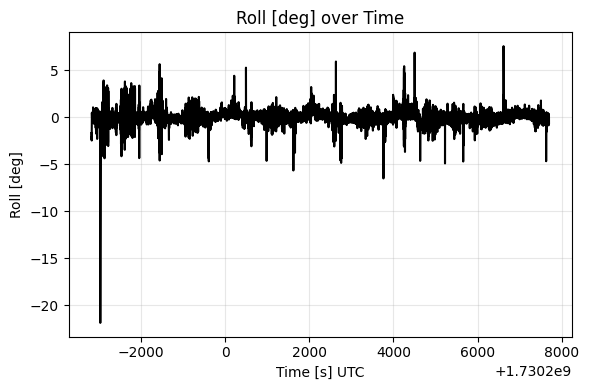

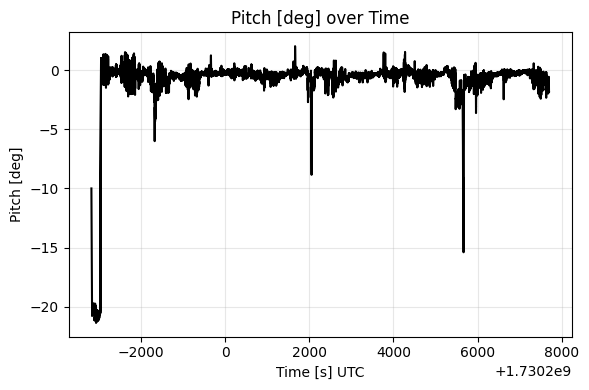

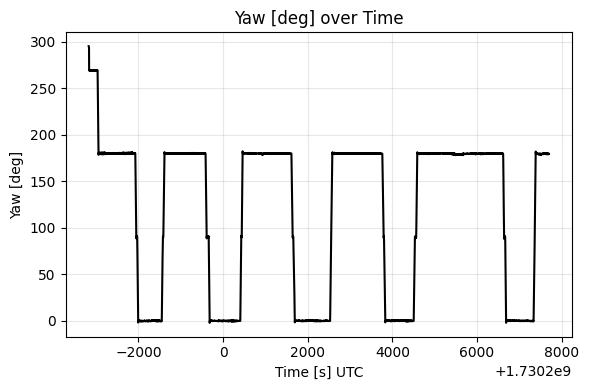

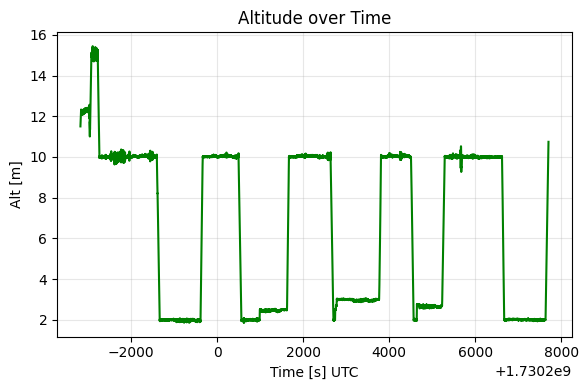

3D Plot: 232670 points
X-axis range: -154.232646 to 48.373658
Y-axis range: -388.336934 to -307.957867
Depth range: 93.40 to 135.31


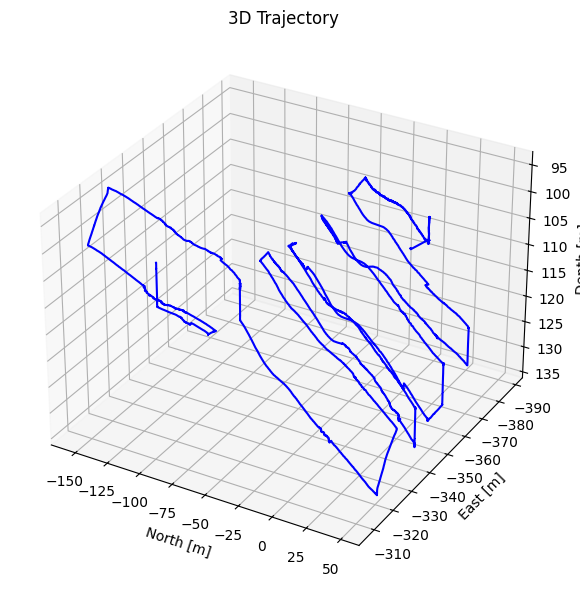

In [7]:
log_data.plot_combined(use_meters=True, origin=origin_deg)

here is start of new code

In [8]:
# Monkey patch the LogData class


def plot_with_transects(
    self,
    transect_csv_paths: list,
    transect_labels: list = None,
    use_meters=False,
    origin=None,
):
    """
    Generates diagnostic plots with main data and overlaid transect segments.
    Uses same foundation as plot_combined with proper axis orientations.

    Parameters:
    -----------
    transect_csv_paths : list
        List of paths to transect CSV files
    transect_labels : list, optional
        Labels for each transect. If None, will use filename
    use_meters : bool, optional
        If True, converts lat/lon to meters.
        If False (default), uses degrees.
    origin : tuple(lat, lon), optional
        Reference point for meter conversion. Required if use_meters=True.
    """
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    import pandas as pd
    import os
    import numpy as np

    # Convert spatial coords for main data (same as plot_combined)
    if use_meters:
        if origin is None:
            raise ValueError("origin must be provided when use_meters=True")
        east, north = self.deg_to_meter_simple(
            self.latitude, self.longitude, origin=origin
        )
        x_coords, y_coords = east, north
        x_label, y_label = "East [m]", "North [m]"
        x3_label, y3_label = "North [m]", "East [m]"  # swapped for 3D
    else:
        x_coords, y_coords = self.longitude, self.latitude
        x_label, y_label = "Lon [deg]", "Lat [deg]"
        x3_label, y3_label = "Lat [deg]", "Lon [deg]"  # swapped for 3D

    # Load transect data
    transects = []
    labels = []
    colors = [
        "red",
        "orange",
        "green",
        "blue",
        "purple",
        "brown",
        "pink",
        "gray",
        "olive",
        "cyan",
    ]

    for i, csv_path in enumerate(transect_csv_paths):
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            df = df.rename(
                columns={
                    "timestamp [unix epoch s]": "timestamp",
                    "latitude [deg]": "latitude",
                    "longitude [deg]": "longitude",
                    "depth [m]": "depth",
                    "roll [deg]": "roll",
                    "pitch [deg]": "pitch",
                    "yaw [deg]": "yaw",
                    "altitude [m]": "altitude",
                }
            )
            df = df[df["altitude"].notna()]

            # Convert transect coordinates (same logic as main data)
            if use_meters:
                t_east, t_north = self.deg_to_meter_simple(
                    df["latitude"].values, df["longitude"].values, origin=origin
                )
                df["x_coords"] = t_east
                df["y_coords"] = t_north
                df["x3_coords"] = t_north  # for 3D: north on x-axis
                df["y3_coords"] = t_east  # for 3D: east on y-axis
            else:
                df["x_coords"] = df["longitude"]
                df["y_coords"] = df["latitude"]
                df["x3_coords"] = df["latitude"]  # for 3D: lat on x-axis
                df["y3_coords"] = df["longitude"]  # for 3D: lon on y-axis

            transects.append(df)

            # Create label
            if transect_labels and i < len(transect_labels):
                labels.append(transect_labels[i])
            else:
                filename = os.path.basename(csv_path)
                labels.append(filename.replace(".csv", ""))
        else:
            print(f"Warning: {csv_path} not found")

    if not transects:
        print("No valid transect files found. Plotting main data only.")
        self.plot_combined(use_meters=use_meters, origin=origin)
        return

    # 1. Position scatter with transects overlaid
    fig, ax = plt.subplots(figsize=(12, 7))  # match plot_combined size
    ax.scatter(x_coords, y_coords, s=5, alpha=0.7, color="blue", label="All data")

    for i, (transect, label) in enumerate(zip(transects, labels)):
        color = colors[i % len(colors)]
        ax.scatter(
            transect["x_coords"],
            transect["y_coords"],
            s=3,
            alpha=0.8,
            color=color,
            label=label,
        )

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title("Position")  # match plot_combined title
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.tight_layout()
    plt.show()

    # 2. Time series plots with transects overlaid
    signals = [
        ("latitude", "Lat [deg]"),
        ("longitude", "Lon [deg]"),
        ("depth", "Depth [m]"),
        ("roll", "Roll [deg]"),
        ("pitch", "Pitch [deg]"),
        ("yaw", "Yaw [deg]"),
    ]

    for attr, ylabel in signals:
        fig, ax = plt.subplots(figsize=(12, 7))  # match plot_combined size
        ax.plot(
            self.timestamp,
            getattr(self, attr),
            color="lightgray",
            alpha=0.7,
            linewidth=1,
            label="All data",
        )

        for i, (transect, label) in enumerate(zip(transects, labels)):
            color = colors[i % len(colors)]
            ax.plot(
                transect["timestamp"],
                transect[attr],
                color=color,
                linewidth=2,
                alpha=0.9,
                label=label,
            )

        ax.set_xlabel("Time [s] UTC")
        ax.set_ylabel(ylabel)

        # Invert y-axis for depth to show 0 at top, positive values downward
        if attr == "depth":
            ax.invert_yaxis()

        ax.set_title(f"{ylabel} over Time")  # simplified title like plot_combined
        ax.grid(True, alpha=0.3)
        ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        fig.tight_layout()
        plt.show()

    # 3. Altitude time series with transects
    fig, ax = plt.subplots(figsize=(12, 7))  # match plot_combined size
    ax.plot(
        self.timestamp,
        self.altitude,
        color="green",
        alpha=1,
        linewidth=1,
        label="All data",
    )

    for i, (transect, label) in enumerate(zip(transects, labels)):
        color = colors[i % len(colors)]
        ax.plot(
            transect["timestamp"],
            transect["altitude"],
            color=color,
            linewidth=2,
            alpha=0.9,
            label=label,
        )

    ax.set_xlabel("Time [s] UTC")
    ax.set_ylabel("Alt [m]")
    ax.set_title("Altitude over Time")  # match plot_combined title
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.tight_layout()
    plt.show()

    # 4. 3D trajectory with proper axis orientation (same as plot_combined)
    # Ensure all arrays have same length
    min_length = min(len(y_coords), len(x_coords), len(self.depth))
    main_x3 = y_coords[:min_length]  # north for x-axis
    main_y3 = x_coords[:min_length]  # east for y-axis
    main_depth = self.depth[:min_length]

    fig = plt.figure(figsize=(7, 6))  # match plot_combined size
    ax = fig.add_subplot(111, projection="3d")
    ax.plot(
        main_x3,
        main_y3,
        main_depth,
        color="blue",
        alpha=0.5,
        linewidth=2,
        label="All data",
    )

    for i, (transect, label) in enumerate(zip(transects, labels)):
        color = colors[i % len(colors)]
        ax.plot(
            transect["x3_coords"],
            transect["y3_coords"],
            transect["depth"],
            color=color,
            linewidth=3,
            alpha=0.9,
            label=label,
        )

    ax.set_xlabel(x3_label)
    ax.set_ylabel(y3_label)
    ax.set_zlabel("Depth [m]")
    ax.invert_zaxis()  # 0 at top, positive down
    ax.invert_yaxis()
    ax.set_title("3D Trajectory")  # match plot_combined title

    # Debug info (same as plot_combined)
    print(f"3D Plot: {len(main_x3)} main points")
    print(f"X-axis range: {main_x3.min():.6f} to {main_x3.max():.6f}")
    print(f"Y-axis range: {main_y3.min():.6f} to {main_y3.max():.6f}")
    print(f"Depth range: {main_depth.min():.2f} to {main_depth.max():.2f}")

    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.tight_layout()
    plt.show()


# Apply monkey patch
LogData.plot_with_transects = plot_with_transects

In [9]:
# Define IMU transect times
# imu_transects = [
#     ("10:50:49", "10:59:00"),
#     ("11:59:26", "12:08:10"),
#     ("12:58:54", "13:07:16"),
#     ("13:10:00", "13:13:16"),
# ]

imu_transects = [
    ("10:50:51", "10:59:06"),
    ("11:23:50", "11:25:04"),
    ("11:26:32", "11:31:35"),
    ("11:59:27", "12:08:17"),
    ("12:25:09", "12:33:33"),
    ("12:58:58", "13:07:20"),
    ("13:10:05", "13:13:22"),
    ("13:43:34", "13:45:00"),
    ("13:45:18", "13:48:29"),
]

print("🔍 DEBUGGING: Let's first test DVL data loading speed...")
print("   Testing just the first transect to see what's slow...")
print()

# Test DVL data loading for just one transect
import datetime

start_str, end_str = imu_transects[0]  # Just test the first one

# Create datetime objects (same as in the function)
base_date = datetime.datetime(2024, 10, 29, tzinfo=datetime.timezone.utc)
start_dt = datetime.datetime.combine(
    base_date.date(),
    datetime.datetime.strptime(start_str, "%H:%M:%S").time(),
    tzinfo=datetime.timezone.utc,
)
end_dt = datetime.datetime.combine(
    base_date.date(),
    datetime.datetime.strptime(end_str, "%H:%M:%S").time(),
    tzinfo=datetime.timezone.utc,
)

print(f"⏰ Time range: {start_dt} to {end_dt}")
print(f"⏰ Duration: {(end_dt - start_dt).total_seconds()} seconds")
print()

print("📊 Testing DVL data loading...")
try:
    import time

    # Test DVL velocity loading
    t0 = time.time()
    vx_dvl = analyzer._MotionAnalyzer__db.get_signal(
        "/sensors/dvl/velocity/D__x",
        start_time=start_dt,
        end_time=end_dt,
        reset_time_stamp_to_zero=False,
    )
    t1 = time.time()
    print(f"   ✅ DVL vx loaded: {len(vx_dvl.data)} points in {t1-t0:.2f} seconds")

    t0 = time.time()
    vy_dvl = analyzer._MotionAnalyzer__db.get_signal(
        "/sensors/dvl/velocity/D__y",
        start_time=start_dt,
        end_time=end_dt,
        reset_time_stamp_to_zero=False,
    )
    t1 = time.time()
    print(f"   ✅ DVL vy loaded: {len(vy_dvl.data)} points in {t1-t0:.2f} seconds")

    # Check data ranges
    if len(vx_dvl.data) > 0:
        print(
            f"   📊 DVL vx range: {min(vx_dvl.data):.3f} to {max(vx_dvl.data):.3f} m/s"
        )
    if len(vy_dvl.data) > 0:
        print(
            f"   📊 DVL vy range: {min(vy_dvl.data):.3f} to {max(vy_dvl.data):.3f} m/s"
        )

    print()
    print("🎯 DVL data loading seems OK. Let's try the simple extraction first...")

except Exception as e:
    print(f"❌ DVL data loading failed: {e}")
    print("   This might be why the function is hanging!")
    print()

# For now, let's just do the simple CSV extraction without DVL dead reckoning
print("🔄 Doing simple CSV extraction first (no dead reckoning)...")
base_navigation_path = r"E:\mjosa_new\get_plots\nav"
main_csv_file = r"E:\mjosa_new\navigation_data\nav_data_from_logfile.csv"

analyzer.get_individual_transect_csvs(
    main_csv_file, base_navigation_path, imu_transects
)

🔍 DEBUGGING: Let's first test DVL data loading speed...
   Testing just the first transect to see what's slow...

⏰ Time range: 2024-10-29 10:50:51+00:00 to 2024-10-29 10:59:06+00:00
⏰ Duration: 495.0 seconds

📊 Testing DVL data loading...
   ✅ DVL vx loaded: 976 points in 0.10 seconds
   ✅ DVL vy loaded: 980 points in 0.09 seconds
   📊 DVL vx range: -0.002 to 0.237 m/s
   📊 DVL vy range: -0.033 to 0.026 m/s

🎯 DVL data loading seems OK. Let's try the simple extraction first...
🔄 Doing simple CSV extraction first (no dead reckoning)...
✅ Transect 10:50:51-10:59:06: 10709 points (yaw range: 179.4° to 180.6°)
   📁 Saved to: E:\mjosa_new\get_plots\nav\105051\nav_data_105051.csv

✅ Transect 11:23:50-11:25:04: 1688 points (yaw range: 179.2° to 180.3°)
   📁 Saved to: E:\mjosa_new\get_plots\nav\112350\nav_data_112350.csv

✅ Transect 11:26:32-11:31:35: 6776 points (yaw range: 179.4° to 180.4°)
   📁 Saved to: E:\mjosa_new\get_plots\nav\112632\nav_data_112632.csv

✅ Transect 11:59:27-12:08:17: 1

🔍 Verifying yaw angle ranges in transect files:
   nav_data_105051.csv: yaw range 179.4° to 180.6°
   nav_data_112350.csv: yaw range 179.2° to 180.3°
   nav_data_112632.csv: yaw range 179.4° to 180.4°
   nav_data_115927.csv: yaw range 179.4° to 180.5°
   nav_data_122509.csv: yaw range 179.2° to 180.4°
   nav_data_125858.csv: yaw range -0.3° to 0.5°
   nav_data_131005.csv: yaw range 178.6° to 179.9°

Expected: yaw values should be roughly in [-180°, +180°] range
Previous problem: yaw values were in [3000°+] range due to unwrapping



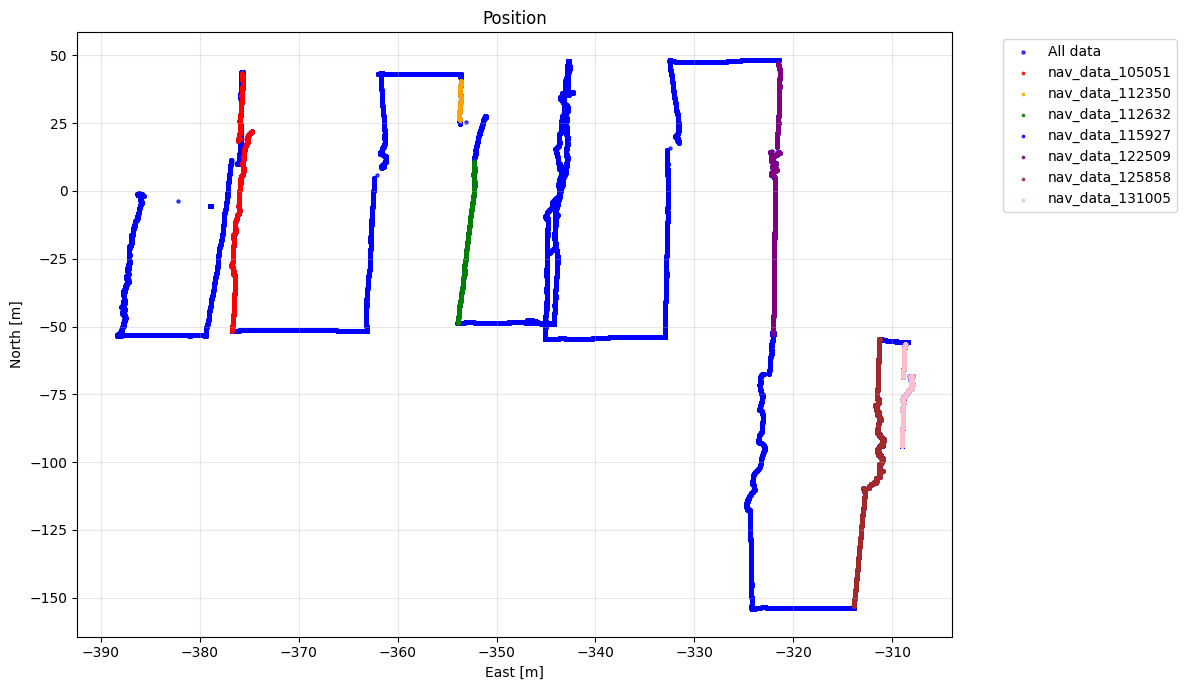

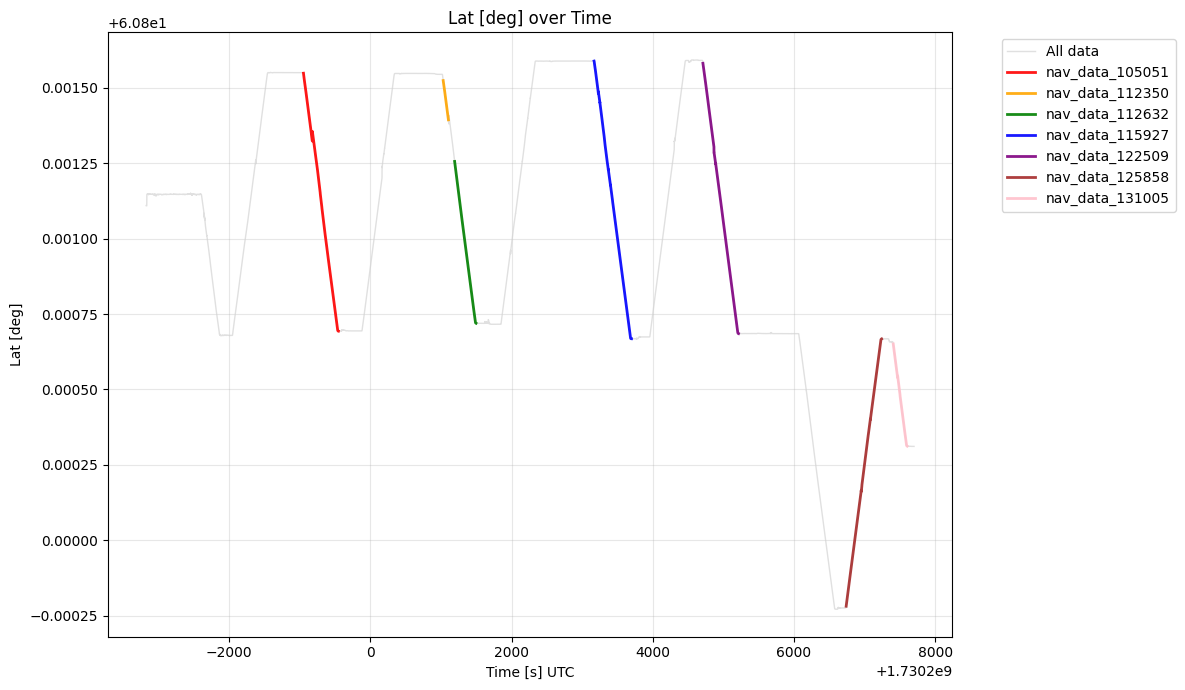

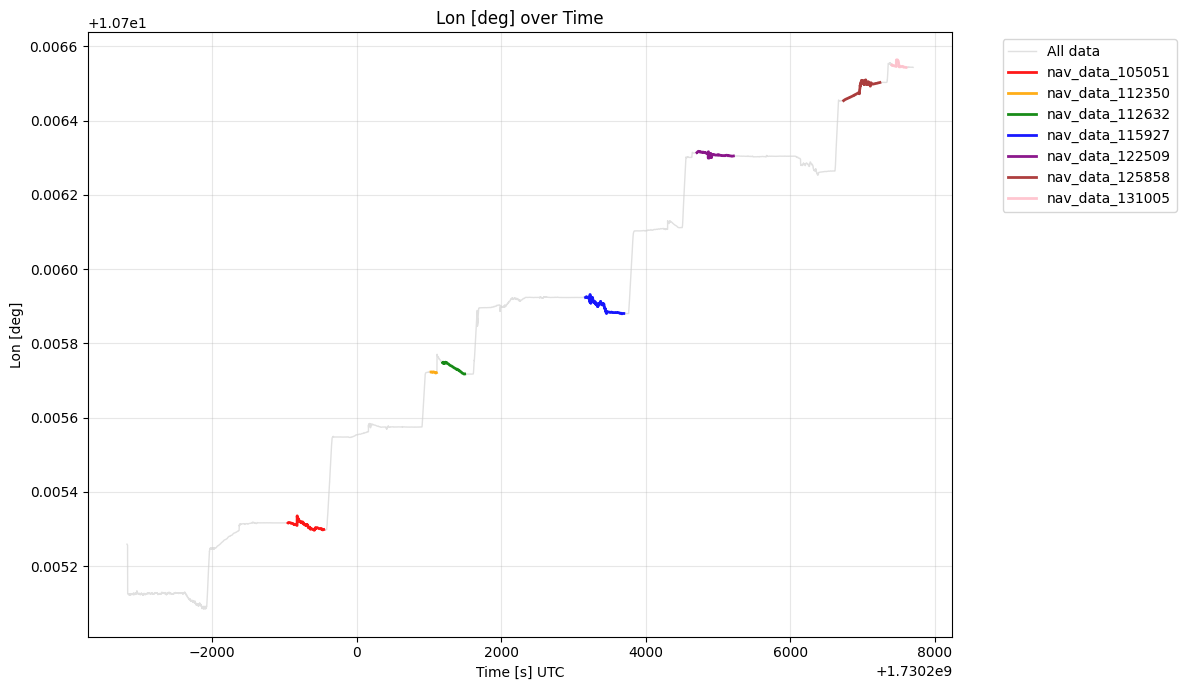

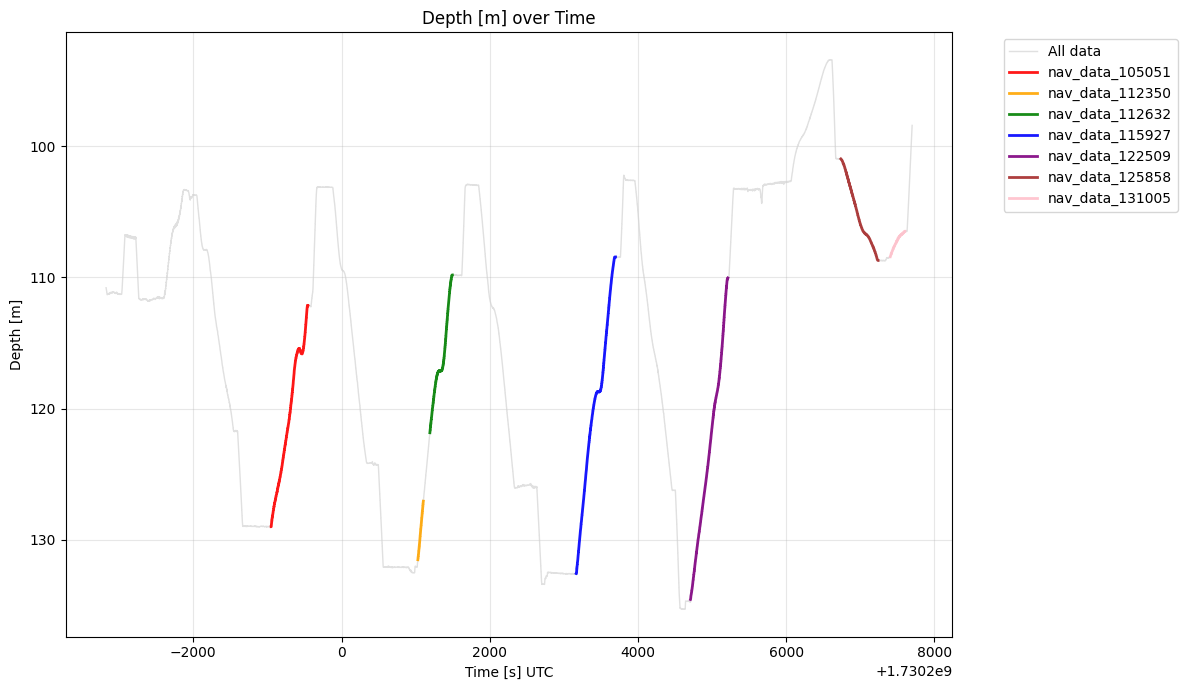

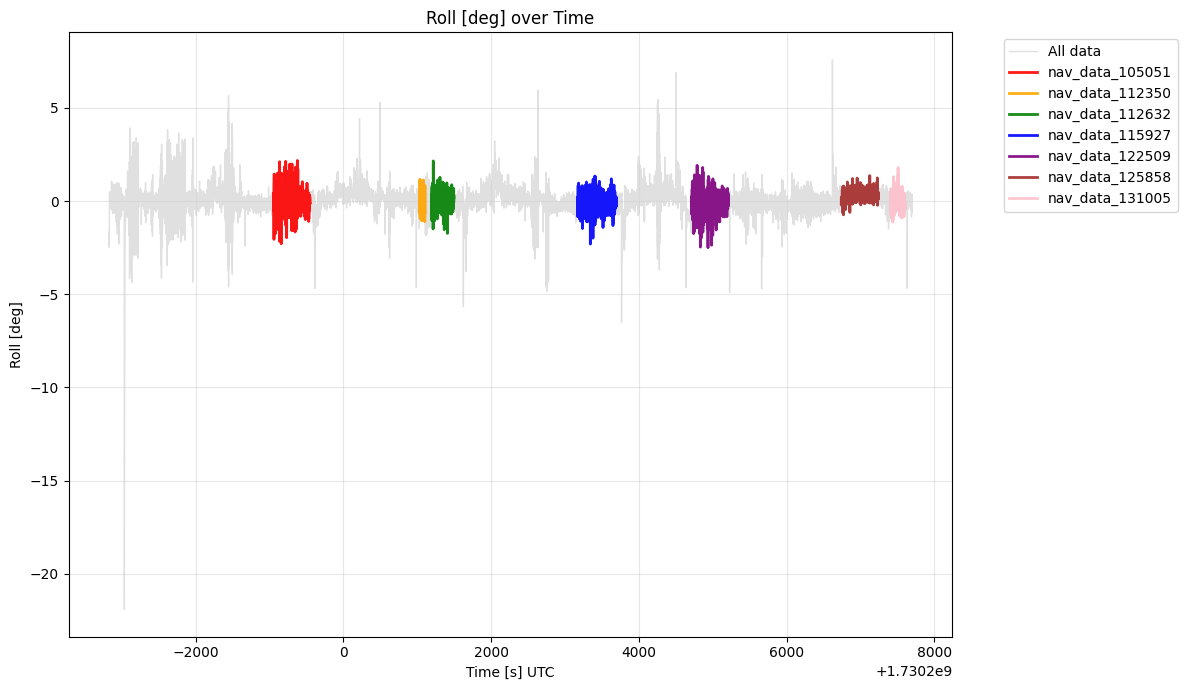

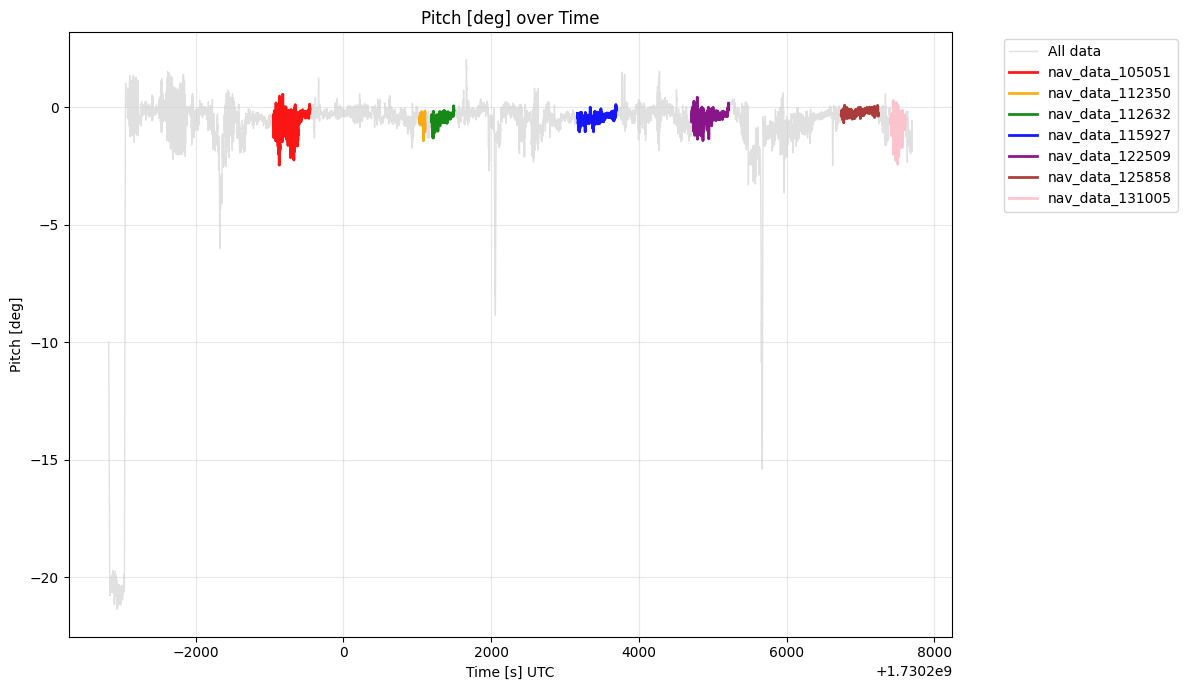

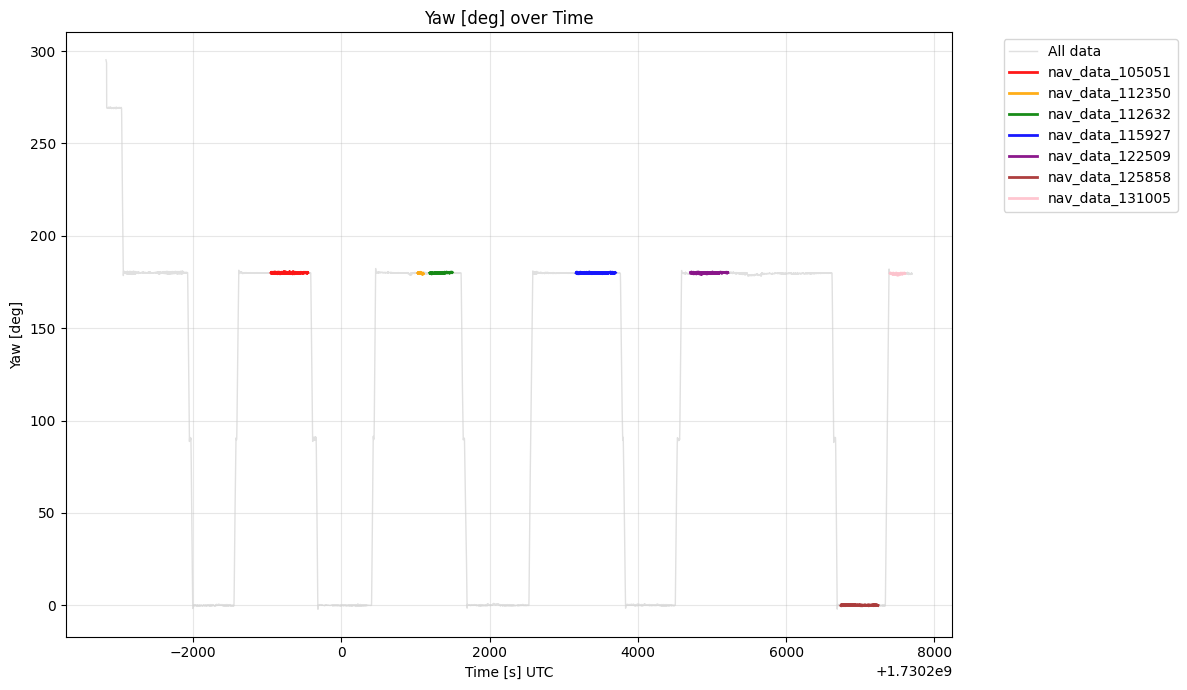

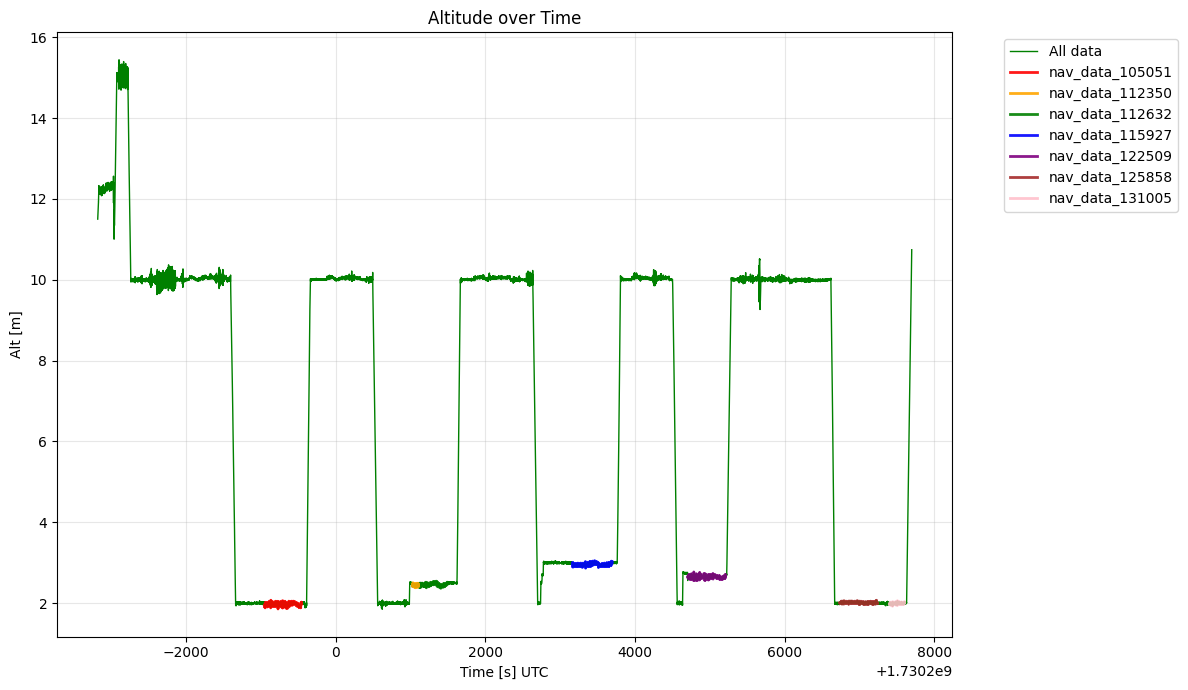

3D Plot: 232670 main points
X-axis range: -154.232646 to 48.373658
Y-axis range: -388.336934 to -307.957867
Depth range: 93.40 to 135.31


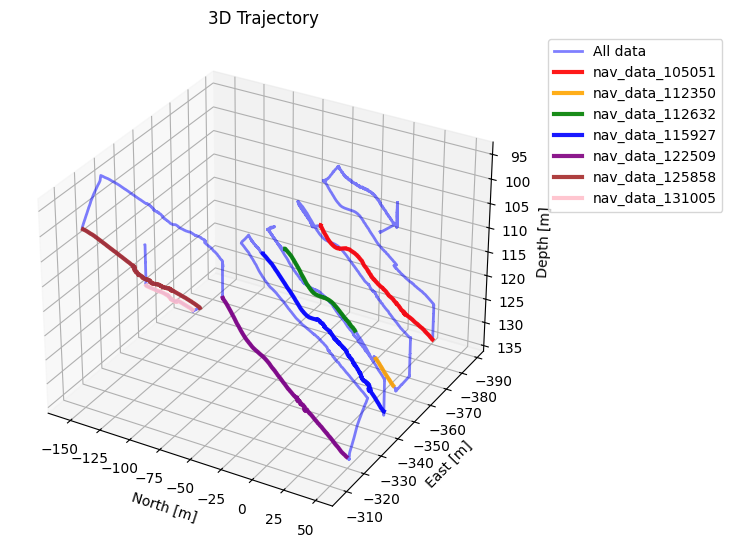

In [10]:
# 1. Load your main navigation data
main_csv = r"E:\mjosa_new\navigation_data\nav_data_from_logfile.csv"
log_data = LogData(main_csv)

# 2. List your transect CSV files
transect_files = [
    r"E:\mjosa_new\get_plots\nav\105051\nav_data_105051.csv",
    r"E:\mjosa_new\get_plots\nav\112350\nav_data_112350.csv",
    r"E:\mjosa_new\get_plots\nav\112632\nav_data_112632.csv",
    r"E:\mjosa_new\get_plots\nav\115927\nav_data_115927.csv",
    r"E:\mjosa_new\get_plots\nav\122509\nav_data_122509.csv",
    r"E:\mjosa_new\get_plots\nav\125858\nav_data_125858.csv",
    r"E:\mjosa_new\get_plots\nav\131005\nav_data_131005.csv",
]


# transect_files = [
#     r"E:\mjosa_new\navigation_data\105049\nav_data_105049.csv",
#     r"E:\mjosa_new\navigation_data\115926\nav_data_115926.csv",
#     r"E:\mjosa_new\navigation_data\125854\nav_data_125854.csv",
#     r"E:\mjosa_new\navigation_data\131000\nav_data_131000.csv",
# ]

# 3. Quick verification that yaw values are now in reasonable range
import pandas as pd

print("🔍 Verifying yaw angle ranges in transect files:")
for file_path in transect_files:
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        if "yaw [deg]" in df.columns:
            yaw_min, yaw_max = df["yaw [deg]"].min(), df["yaw [deg]"].max()
            filename = os.path.basename(file_path)
            print(f"   {filename}: yaw range {yaw_min:.1f}° to {yaw_max:.1f}°")
        else:
            print(f"   {os.path.basename(file_path)}: No yaw column found!")
    else:
        print(f"   {os.path.basename(file_path)}: File not found!")

print()
print("Expected: yaw values should be roughly in [-180°, +180°] range")
print("Previous problem: yaw values were in [3000°+] range due to unwrapping")
print()

# 4. Plot with corrected transect data
# %matplotlib tk
log_data.plot_with_transects(transect_files, use_meters=True, origin=origin_deg)

In [11]:
# 🎯 NEW DVL Dead Reckoning with CONSTANT HEADING (like your original method!)
print("🚀 Testing DVL dead reckoning with constant heading approach...")
print("   ✅ Uses YOUR original method: constant bearing from start to end")
print("   ✅ But with actual DVL speeds instead of constant 0.2 m/s")
print("   ✅ Should be much faster and more reliable!")
print()

# Test on just one file first
test_csv = r"E:\mjosa_new\navigation_data\105049\nav_data_105049.csv"

if os.path.exists(test_csv):
    print(f"📁 Testing with: {os.path.basename(test_csv)}")

    import time

    start_time = time.time()

    try:
        # Use the new DVL method that follows your constant heading approach
        dr_path = analyzer.create_dvl_velocity_dead_reckoned_csv_v2(
            test_csv, output_suffix="_dr_dvl_v2", adjust_speed_to_hit_end=False
        )

        end_time = time.time()
        print(f"⏱️  Total time: {end_time - start_time:.2f} seconds")

        if dr_path and os.path.exists(dr_path):
            print(f"✅ Success! Much faster with constant heading approach")

            # Compare with original
            import pandas as pd

            df_orig = pd.read_csv(test_csv)
            df_dr = pd.read_csv(dr_path)

            print(f"📊 Points: orig={len(df_orig)}, DR={len(df_dr)}")

            if "dr_bearing [deg]" in df_dr.columns:
                bearing = df_dr["dr_bearing [deg]"].iloc[0]
                print(f"🧭 Constant bearing: {bearing:.2f}°")

            if "dvl_speed [m/s]" in df_dr.columns:
                avg_dvl_speed = df_dr["dvl_speed [m/s]"].mean()
                print(f"🏃 Average DVL speed: {avg_dvl_speed:.3f} m/s")

        else:
            print("❌ DVL dead reckoning failed")

    except Exception as e:
        end_time = time.time()
        print(f"❌ Error after {end_time - start_time:.2f} seconds: {e}")
        import traceback

        print(f"Full error: {traceback.format_exc()}")

else:
    print(f"❌ Test file not found: {test_csv}")
    print("   Run the transect extraction cell first")

🚀 Testing DVL dead reckoning with constant heading approach...
   ✅ Uses YOUR original method: constant bearing from start to end
   ✅ But with actual DVL speeds instead of constant 0.2 m/s
   ✅ Should be much faster and more reliable!

📁 Testing with: nav_data_105049.csv
🚀 DVL dead reckoning (constant heading): nav_data_105049.csv
   🧭 Constant bearing: -179.41°
   📊 DVL speed range: 0.023 to 0.238 m/s
   📊 Average DVL speed: 0.197 m/s
   ✅ DVL DR complete: -179.41°, avg speed 0.197 m/s
   📏 Original distance: 95.3 m
   📏 DR distance: 96.8 m
   💾 Saved: nav_data_105049_dr_dvl_v2.csv
⏱️  Total time: 0.36 seconds
✅ Success! Much faster with constant heading approach
📊 Points: orig=10626, DR=10626
🏃 Average DVL speed: 0.197 m/s


📊 Comparison of different approaches:
   🔵 Original: Simple extraction from main CSV
   🟠 _dr: Constant velocity dead reckoning (old)
   🟢 _dr_dvl: DVL velocity dead reckoning (new - should be better!)



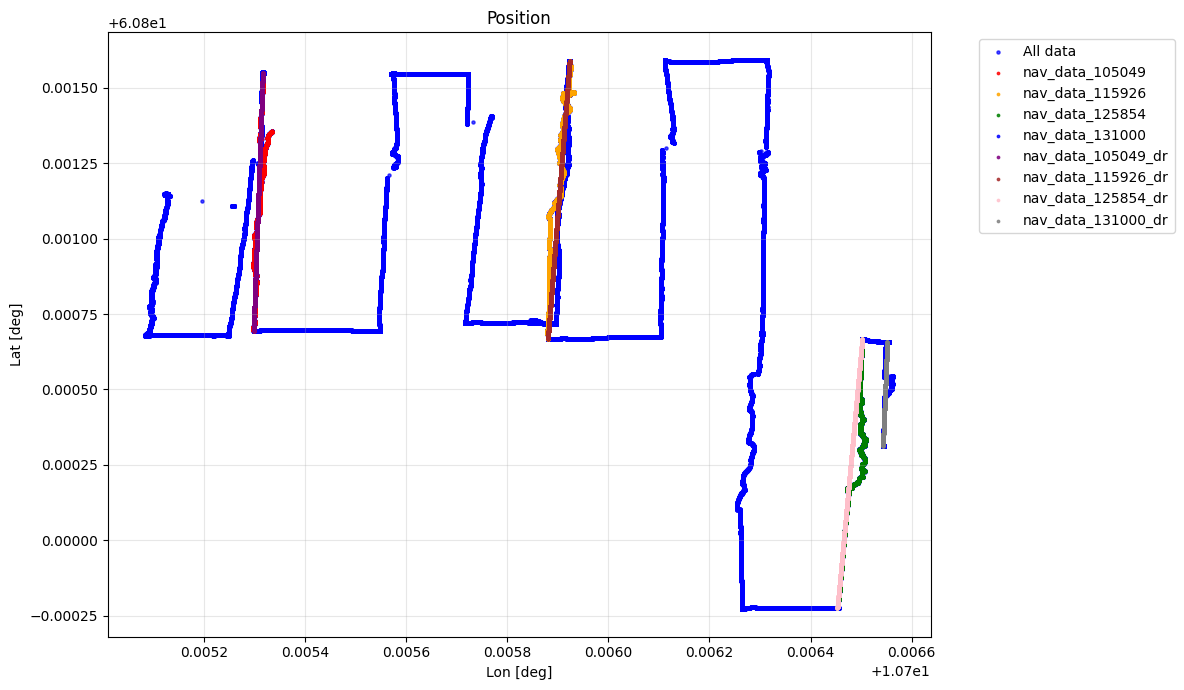

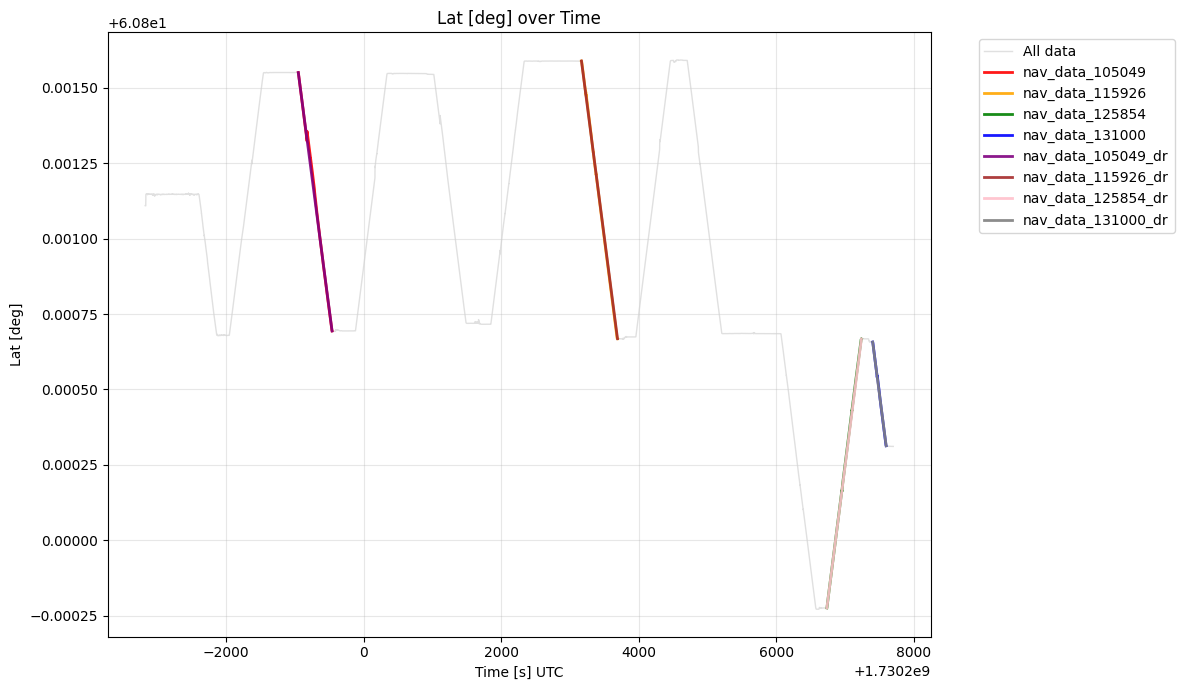

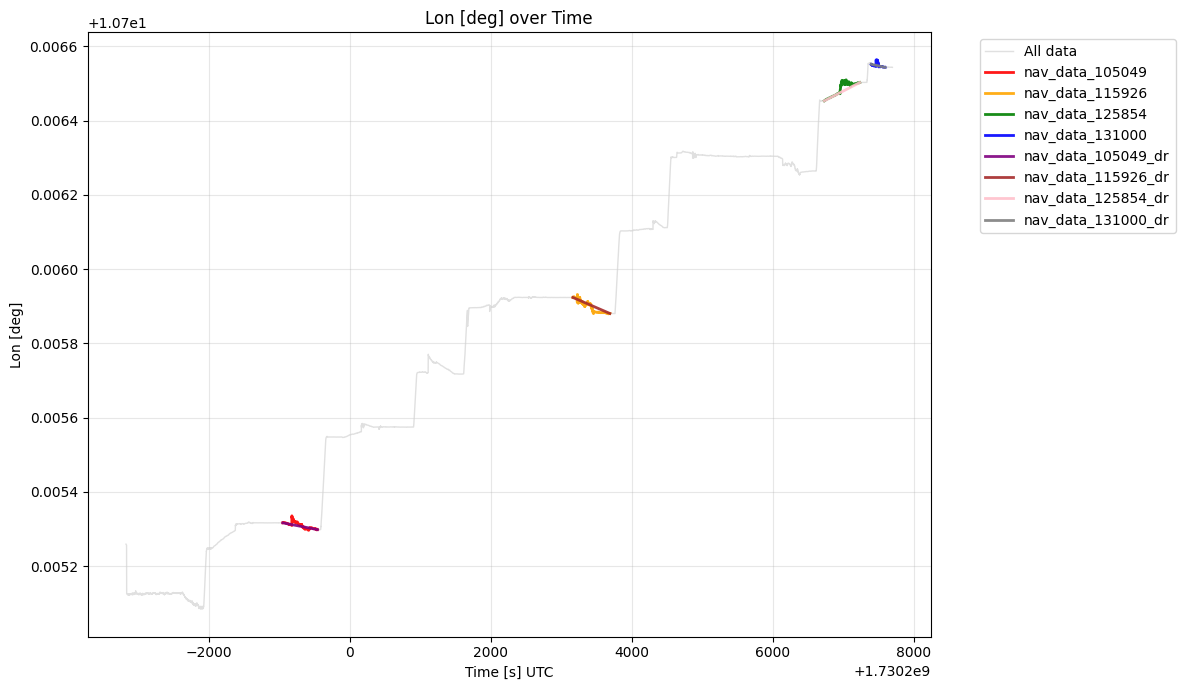

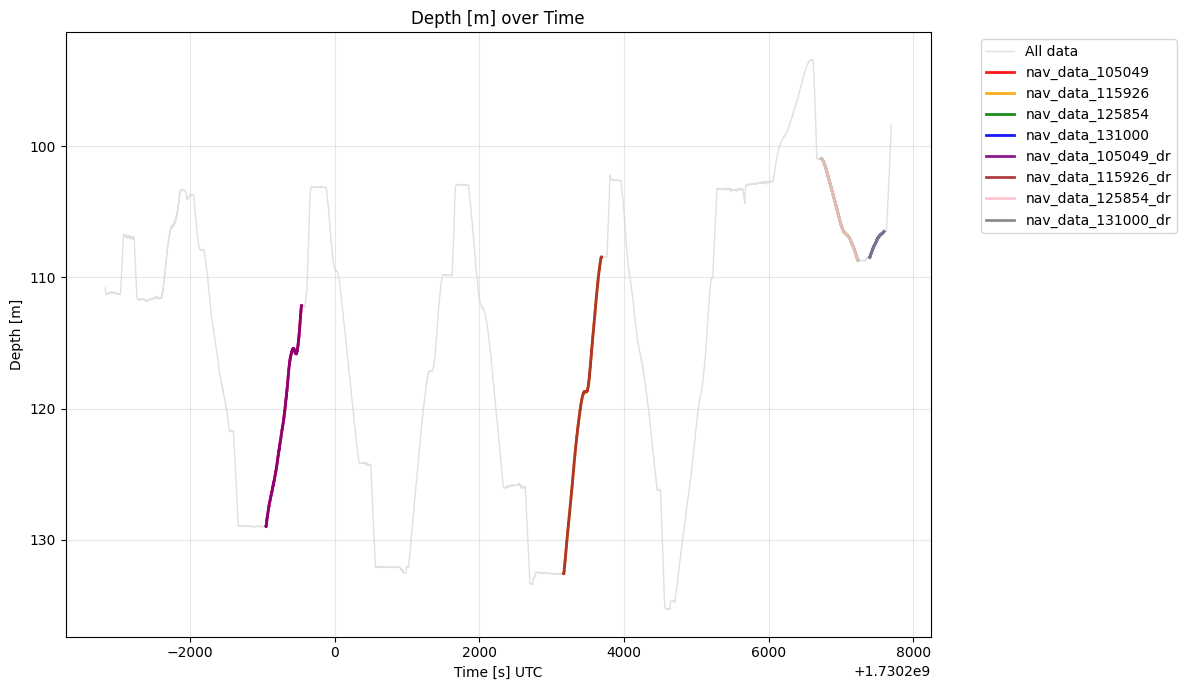

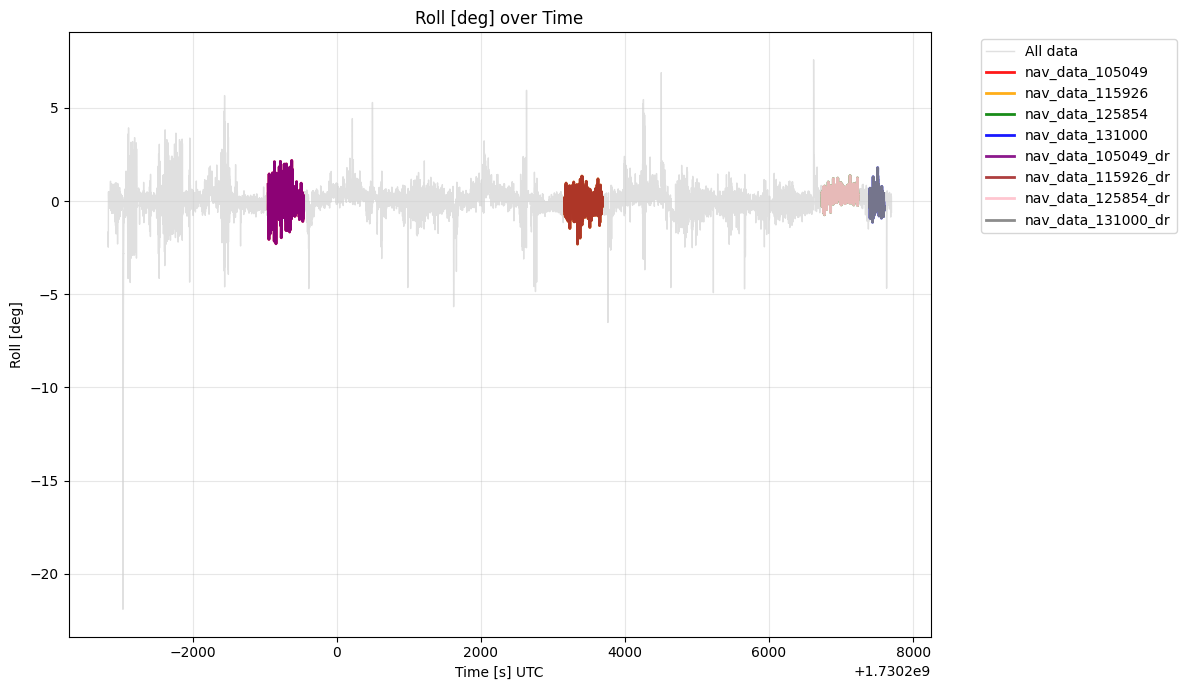

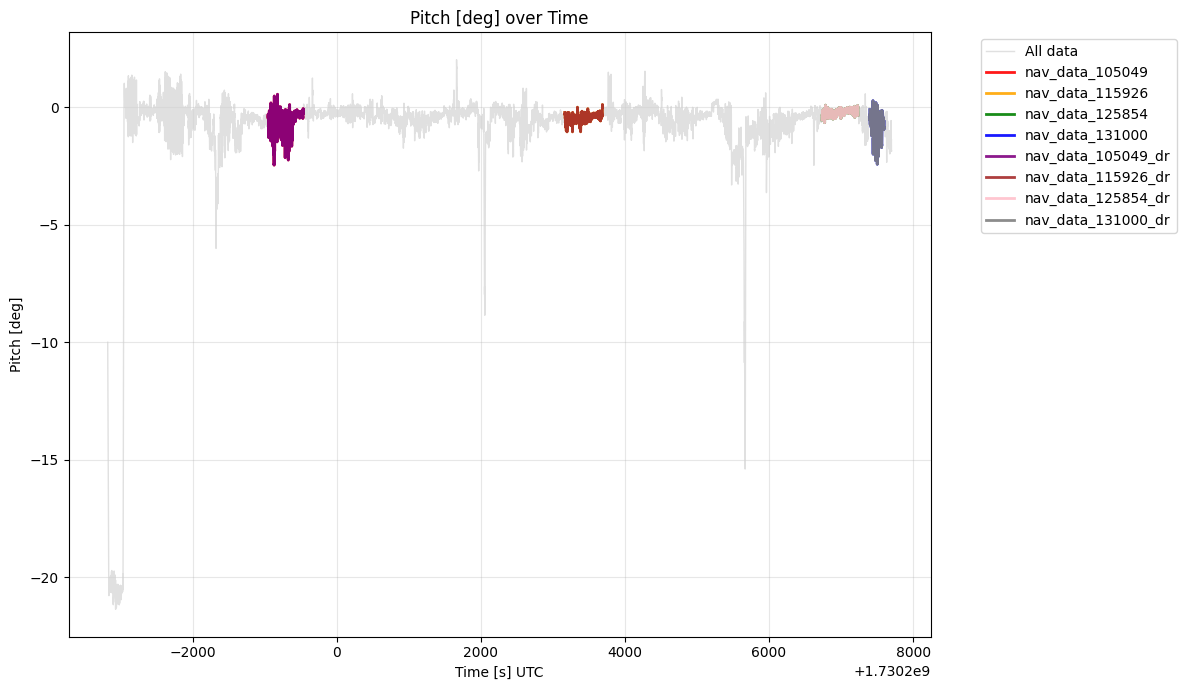

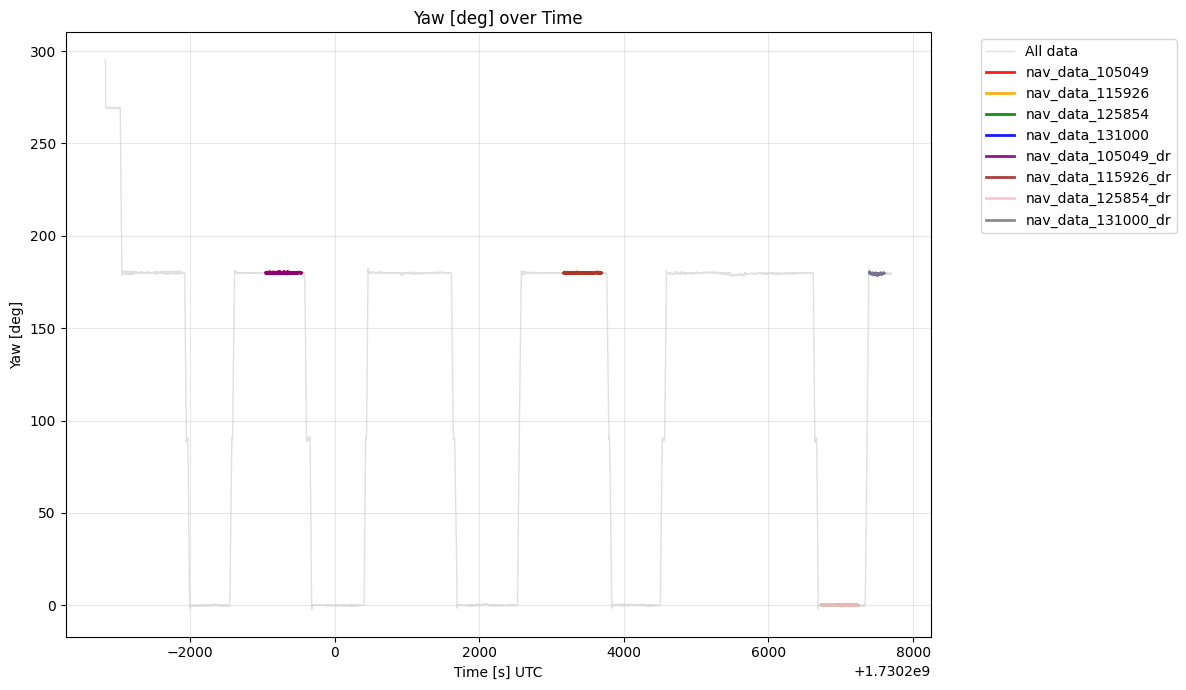

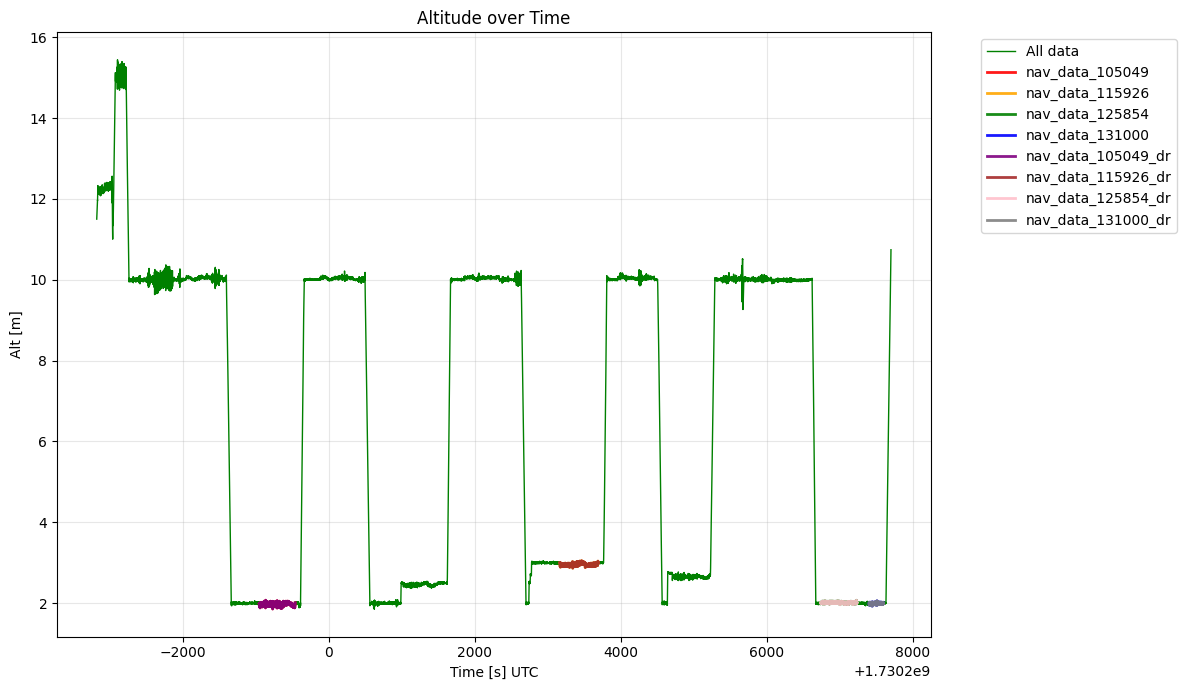

3D Plot: 232670 main points
X-axis range: 60.799772 to 60.801592
Y-axis range: 10.705084 to 10.706564
Depth range: 93.40 to 135.31


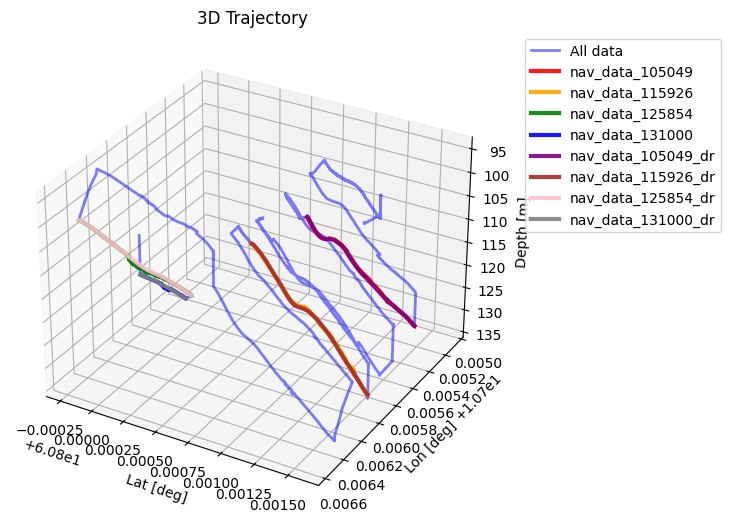

In [26]:
# 1. Load your main navigation data
main_csv = r"E:\mjosa_new\navigation_data\nav_data_from_logfile.csv"
log_data = LogData(main_csv)

# 2. List your transect CSV files - comparing different approaches
# Definer transect_files med _dr-varianter inkludert
transect_files = [
    # Original transects (simple extraction from main CSV)
    r"E:\mjosa_new\navigation_data\105049\nav_data_105049.csv",
    r"E:\mjosa_new\navigation_data\115926\nav_data_115926.csv",
    r"E:\mjosa_new\navigation_data\125854\nav_data_125854.csv",
    r"E:\mjosa_new\navigation_data\131000\nav_data_131000.csv",
    # OLD constant velocity dead reckoning (for comparison)
    r"E:\mjosa_new\navigation_data\105049\nav_data_105049_dr.csv",
    r"E:\mjosa_new\navigation_data\115926\nav_data_115926_dr.csv",
    r"E:\mjosa_new\navigation_data\125854\nav_data_125854_dr.csv",
    r"E:\mjosa_new\navigation_data\131000\nav_data_131000_dr.csv",
]


# transect_files = [
#     # Original transects (simple extraction from main CSV)
#     r"E:\mjosa_new\navigation_data\105049\nav_data_105049.csv",
#     r"E:\mjosa_new\navigation_data\115926\nav_data_115926.csv",
#     r"E:\mjosa_new\navigation_data\125854\nav_data_125854.csv",
#     r"E:\mjosa_new\navigation_data\131000\nav_data_131000.csv",
#     # OLD constant velocity dead reckoning (for comparison)
#     r"E:\mjosa_new\navigation_data\105049\nav_data_105049_dr.csv",
#     r"E:\mjosa_new\navigation_data\115926\nav_data_115926_dr.csv",
#     r"E:\mjosa_new\navigation_data\125854\nav_data_125854_dr.csv",
#     r"E:\mjosa_new\navigation_data\131000\nav_data_131000_dr.csv",
#     # NEW DVL velocity dead reckoning (should be much more accurate!)
#     r"E:\mjosa_new\navigation_data\105049\nav_data_105049_dr_dvl.csv",
#     r"E:\mjosa_new\navigation_data\115926\nav_data_115926_dr_dvl.csv",
#     r"E:\mjosa_new\navigation_data\125854\nav_data_125854_dr_dvl.csv",
#     r"E:\mjosa_new\navigation_data\131000\nav_data_131000_dr_dvl.csv",
# ]

print("📊 Comparison of different approaches:")
print("   🔵 Original: Simple extraction from main CSV")
print("   🟠 _dr: Constant velocity dead reckoning (old)")
print("   🟢 _dr_dvl: DVL velocity dead reckoning (new - should be better!)")
print()

# %matplotlib tk
log_data.plot_with_transects(transect_files)

# Dead Reckoning Comparison

Now let's create both your original constant velocity dead reckoning files and the new DVL-based approach for comparison.

In [25]:
# 🟠 METHOD 1: Your Original Constant Velocity Dead Reckoning
print("🔄 Creating dead reckoning files with YOUR original method...")
print("   ✅ Uses constant 0.2 m/s speed")
print("   ✅ Constant bearing from start to end position")
print("   ✅ Proven method that works reliably")
print()

# Your original transect files (simple extraction from main CSV)
# original_transect_files = [
#     r"E:\mjosa_new\navigation_data\105049\nav_data_105049.csv",
#     r"E:\mjosa_new\navigation_data\115926\nav_data_115926.csv",
#     r"E:\mjosa_new\navigation_data\125854\nav_data_125854.csv",
#     r"E:\mjosa_new\navigation_data\131000\nav_data_131000.csv",
# ]

original_transect_files = [
    r"E:\mjosa_new\get_plots\nav\105051\nav_data_105051.csv",
    r"E:\mjosa_new\get_plots\nav\112350\nav_data_112350.csv",
    r"E:\mjosa_new\get_plots\nav\112632\nav_data_112632.csv",
    r"E:\mjosa_new\get_plots\nav\115927\nav_data_115927.csv",
    r"E:\mjosa_new\get_plots\nav\122509\nav_data_122509.csv",
    r"E:\mjosa_new\get_plots\nav\125858\nav_data_125858.csv",
    r"E:\mjosa_new\get_plots\nav\131005\nav_data_131005.csv",
]


# Create dead reckoning versions with your original method
dr_files_original = []
for csv_file in original_transect_files:
    if os.path.exists(csv_file):
        print(f"📁 Processing: {os.path.basename(csv_file)}")

        try:
            # Use YOUR original constant velocity method
            dr_path = analyzer.create_constant_body_vel_dead_reckoned_csv(
                csv_file,
                output_suffix="_dr",
                adjust_speed_to_hit_end=True,  # Your original approach
            )

            if dr_path and os.path.exists(dr_path):
                dr_files_original.append(dr_path)
                print(f"   ✅ Created: {os.path.basename(dr_path)}")
            else:
                print(f"   ❌ Failed to create DR file")

        except Exception as e:
            print(f"   ❌ Error: {e}")
    else:
        print(f"   ❌ Input file not found: {os.path.basename(csv_file)}")

print(
    f"\n🎯 Original DR method completed: {len(dr_files_original)}/{len(original_transect_files)} files created"
)
print("Files created:")
for f in dr_files_original:
    print(f"   • {os.path.basename(f)}")

🔄 Creating dead reckoning files with YOUR original method...
   ✅ Uses constant 0.2 m/s speed
   ✅ Constant bearing from start to end position
   ✅ Proven method that works reliably

📁 Processing: nav_data_105051.csv
[DR] nav_data_105051.csv → nav_data_105051_dr.csv (-179.41°, 0.192 m/s)
   ✅ Created: nav_data_105051_dr.csv
📁 Processing: nav_data_112350.csv
[DR] nav_data_112350.csv → nav_data_112350_dr.csv (-179.53°, 0.196 m/s)
   ✅ Created: nav_data_112350_dr.csv
📁 Processing: nav_data_112632.csv
[DR] nav_data_112632.csv → nav_data_112632_dr.csv (-178.42°, 0.197 m/s)
   ✅ Created: nav_data_112632_dr.csv
📁 Processing: nav_data_115927.csv
[DR] nav_data_115927.csv → nav_data_115927_dr.csv (-178.69°, 0.193 m/s)
   ✅ Created: nav_data_115927_dr.csv
📁 Processing: nav_data_122509.csv
[DR] nav_data_122509.csv → nav_data_122509_dr.csv (-179.72°, 0.198 m/s)
   ✅ Created: nav_data_122509_dr.csv
📁 Processing: nav_data_125858.csv
[DR] nav_data_125858.csv → nav_data_125858_dr.csv (1.54°, 0.196 m/s)

In [14]:
# 🟢 METHOD 2: New DVL Velocity Dead Reckoning (Constant Heading)
print("\n🚀 Creating dead reckoning files with NEW DVL method...")
print("   ✅ Uses actual DVL velocity measurements")
print("   ✅ Constant bearing like your original method")
print("   ✅ Should be more accurate than constant 0.2 m/s")
print("   ✅ Falls back to your method if DVL data unavailable")
print()

import time

# Create DVL dead reckoning versions
dr_files_dvl = []
for csv_file in original_transect_files:
    if os.path.exists(csv_file):
        print(f"📁 Processing: {os.path.basename(csv_file)}")

        start_time = time.time()
        try:
            # Use NEW DVL method with constant heading (like your original)
            dr_path = analyzer.create_dvl_velocity_dead_reckoned_csv_v2(
                csv_file, output_suffix="_dr_dvl_v2", adjust_speed_to_hit_end=False
            )

            end_time = time.time()
            processing_time = end_time - start_time

            if dr_path and os.path.exists(dr_path):
                dr_files_dvl.append(dr_path)
                print(
                    f"   ✅ Created: {os.path.basename(dr_path)} ({processing_time:.2f}s)"
                )

                # Quick stats on the DVL data
                import pandas as pd

                df = pd.read_csv(dr_path)
                if "dvl_speed [m/s]" in df.columns:
                    avg_speed = df["dvl_speed [m/s]"].mean()
                    print(
                        f"      📊 Avg DVL speed: {avg_speed:.3f} m/s (vs 0.2 m/s constant)"
                    )
                if "dr_bearing [deg]" in df.columns:
                    bearing = df["dr_bearing [deg]"].iloc[0]
                    print(f"      🧭 Constant bearing: {bearing:.1f}°")

            else:
                print(f"   ❌ Failed to create DVL DR file")

        except Exception as e:
            end_time = time.time()
            processing_time = end_time - start_time
            print(f"   ❌ Error after {processing_time:.2f}s: {e}")
    else:
        print(f"   ❌ Input file not found: {os.path.basename(csv_file)}")

print(
    f"\n🎯 DVL DR method completed: {len(dr_files_dvl)}/{len(original_transect_files)} files created"
)
print("Files created:")
for f in dr_files_dvl:
    print(f"   • {os.path.basename(f)}")


🚀 Creating dead reckoning files with NEW DVL method...
   ✅ Uses actual DVL velocity measurements
   ✅ Constant bearing like your original method
   ✅ Should be more accurate than constant 0.2 m/s
   ✅ Falls back to your method if DVL data unavailable

📁 Processing: nav_data_105049.csv
🚀 DVL dead reckoning (constant heading): nav_data_105049.csv
   🧭 Constant bearing: -179.41°
   📊 DVL speed range: 0.023 to 0.238 m/s
   📊 Average DVL speed: 0.197 m/s
   ✅ DVL DR complete: -179.41°, avg speed 0.197 m/s
   📏 Original distance: 95.3 m
   📏 DR distance: 96.8 m
   💾 Saved: nav_data_105049_dr_dvl_v2.csv
   ✅ Created: nav_data_105049_dr_dvl_v2.csv (0.37s)
      📊 Avg DVL speed: 0.197 m/s (vs 0.2 m/s constant)
📁 Processing: nav_data_115926.csv
🚀 DVL dead reckoning (constant heading): nav_data_115926.csv
   🧭 Constant bearing: -178.69°
   📊 DVL speed range: 0.001 to 0.229 m/s
   📊 Average DVL speed: 0.199 m/s
   ✅ DVL DR complete: -178.69°, avg speed 0.199 m/s
   📏 Original distance: 102.4 m
 


📊 Now let's compare all three approaches:
   🔵 Original: Simple extraction from main CSV (real GNSS positions)
   🟠 _dr: Your original constant velocity dead reckoning
   🟢 _dr_dvl_v2: New DVL velocity dead reckoning


🎯 Plotting 12 files for comparison...


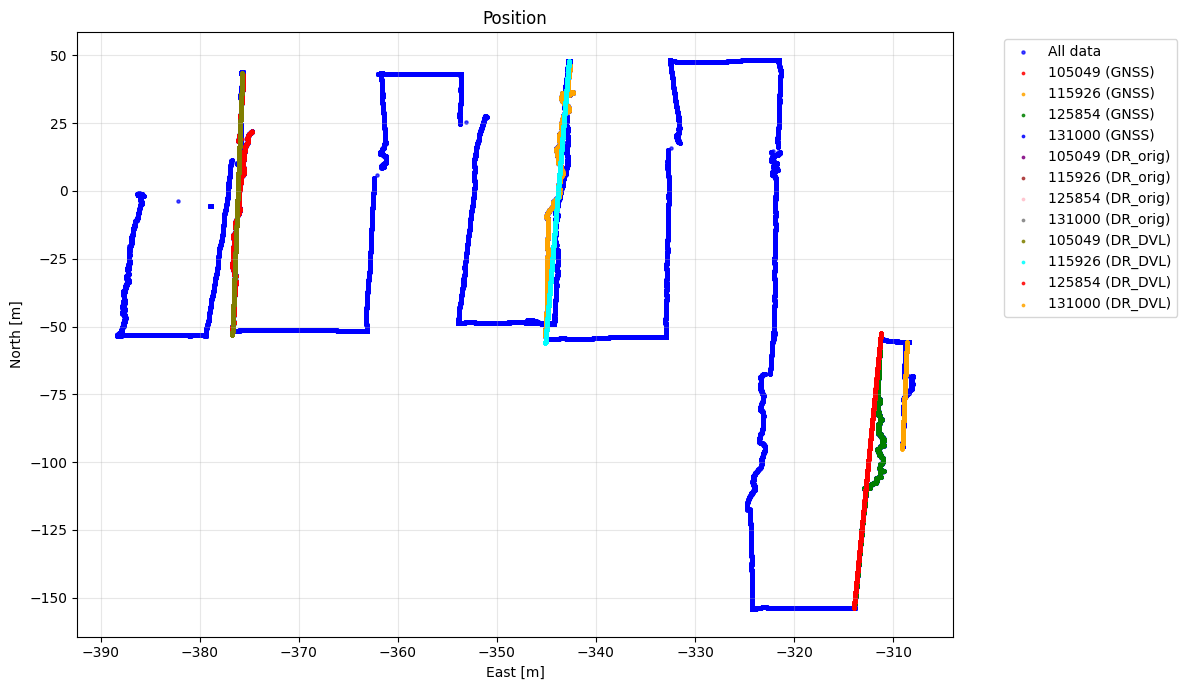

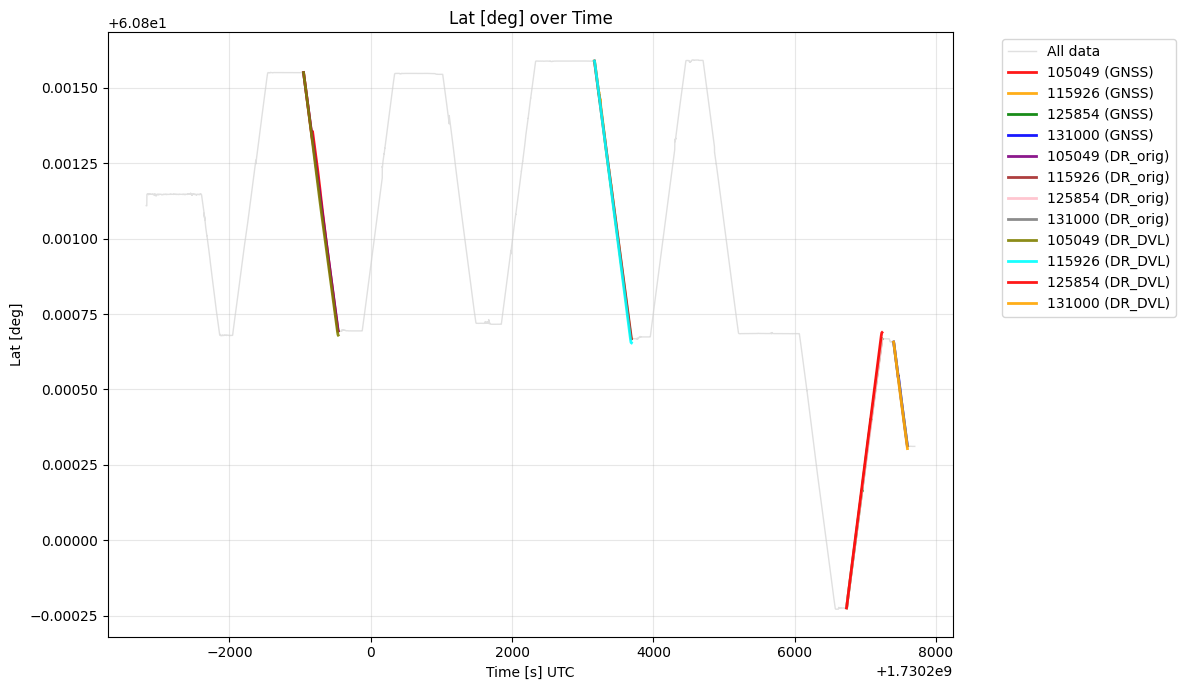

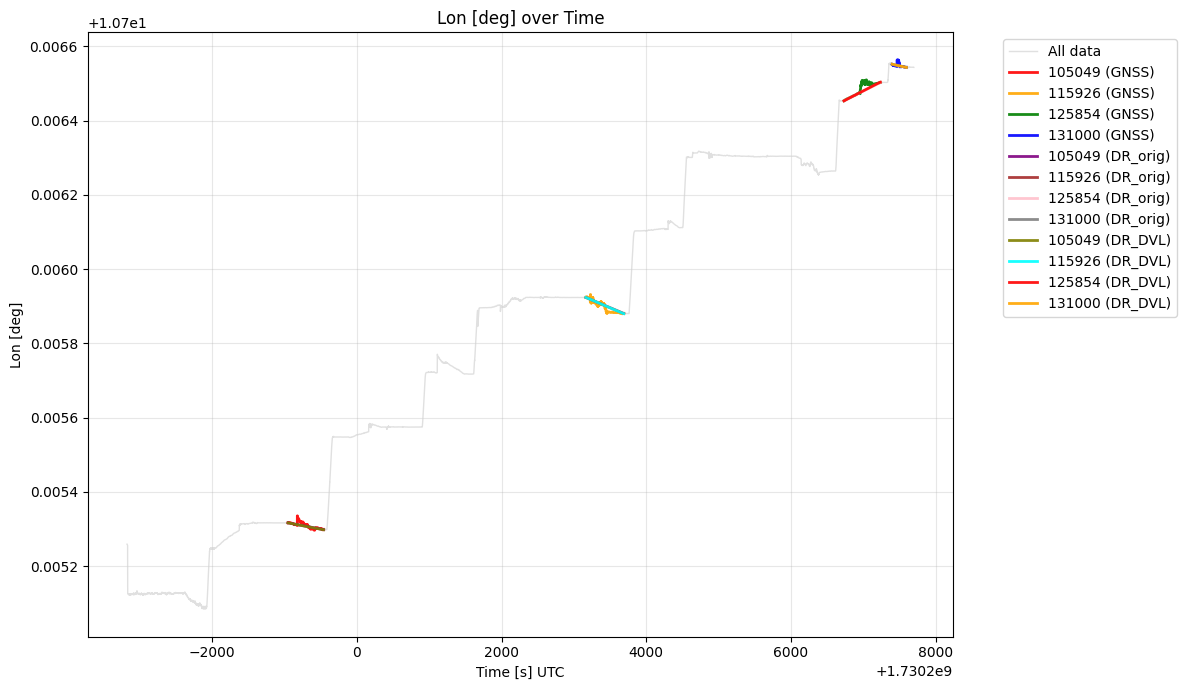

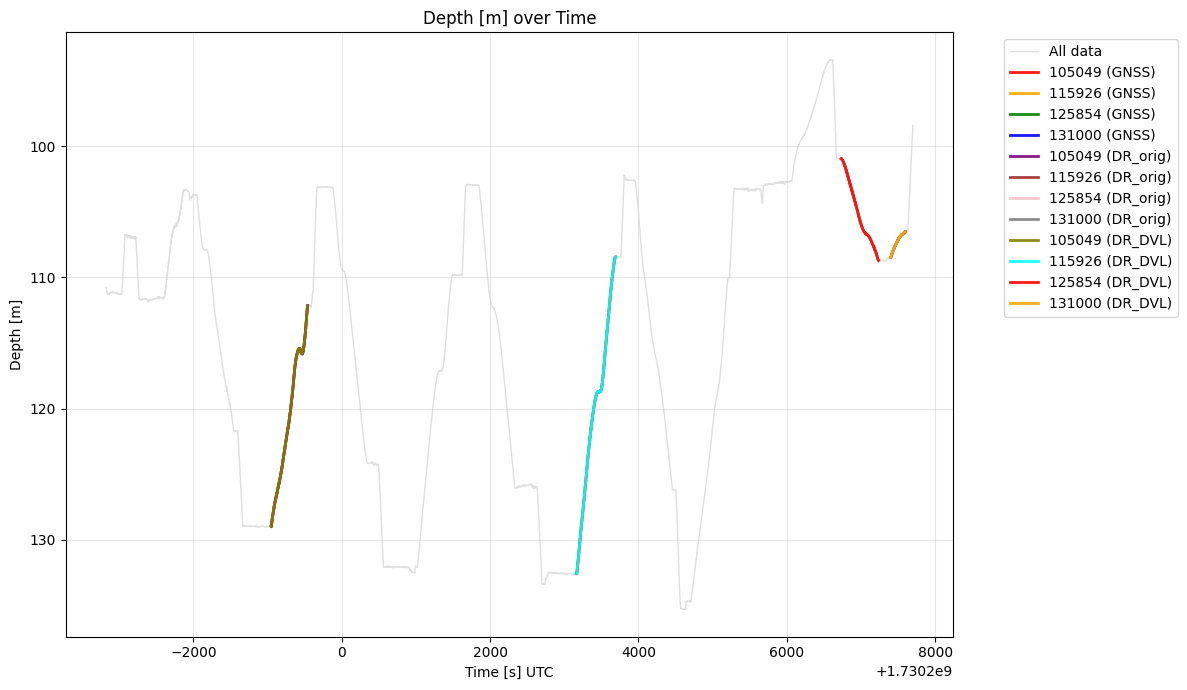

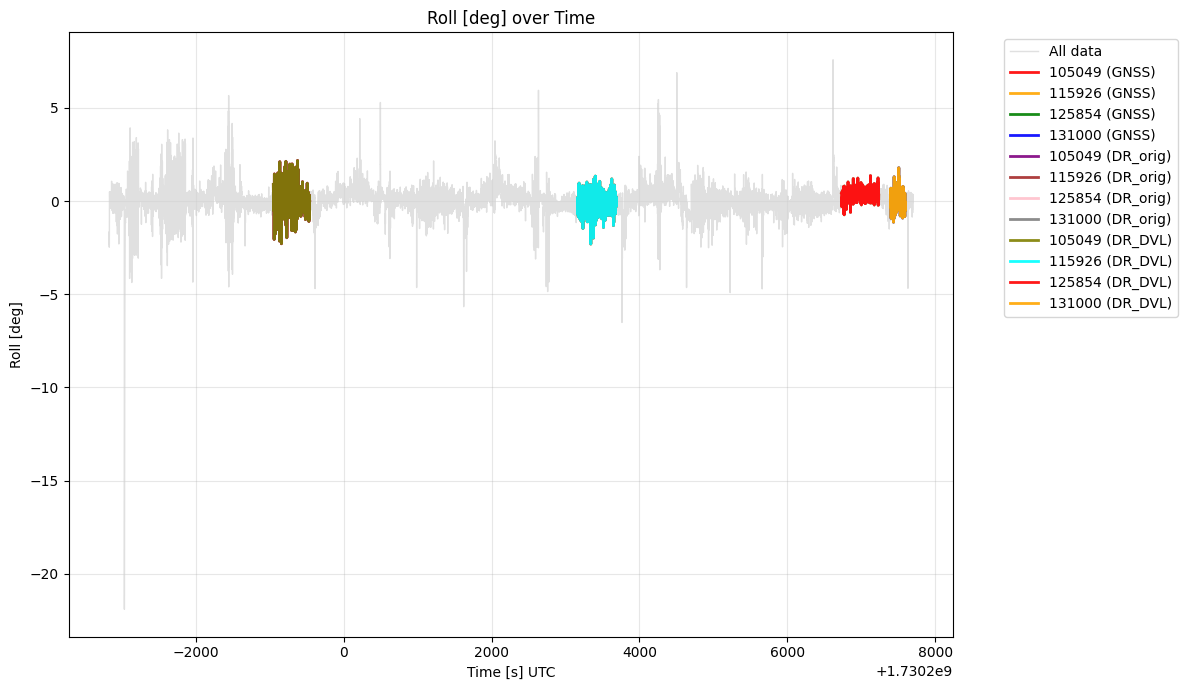

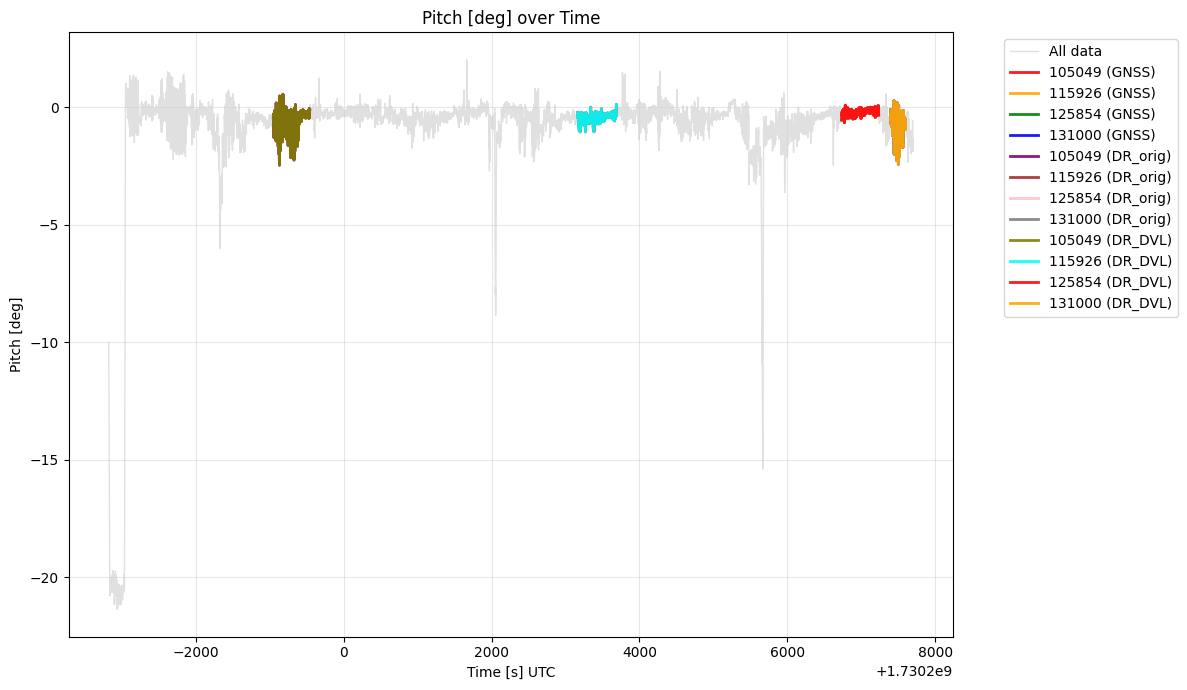

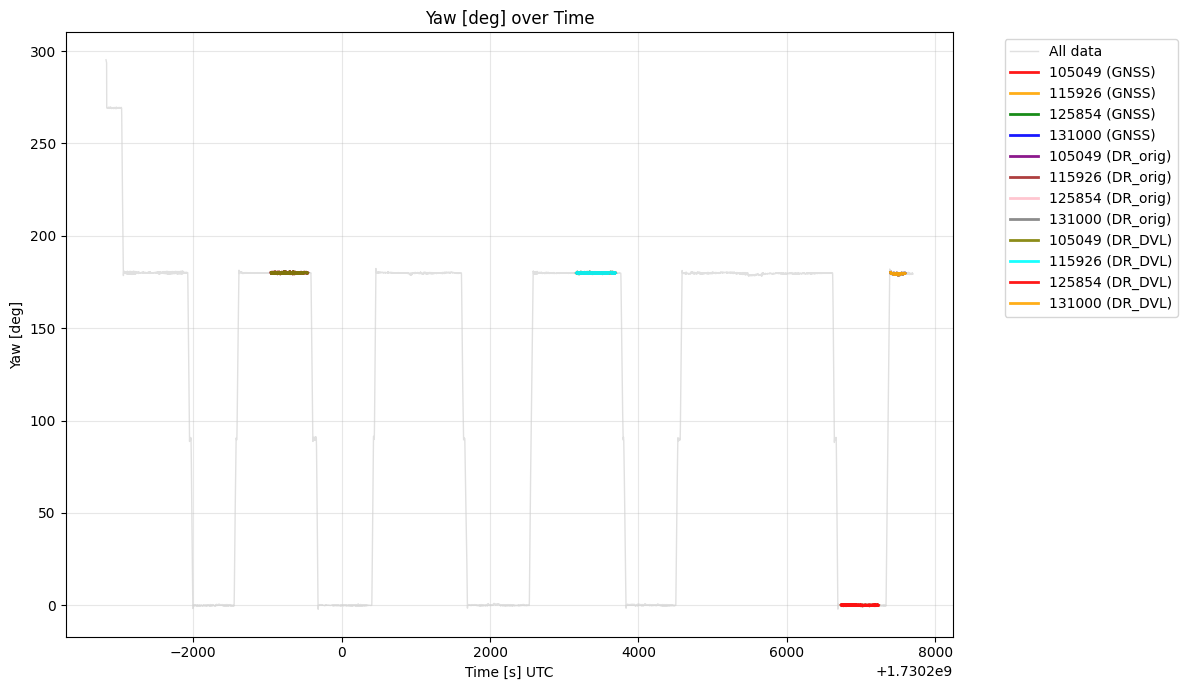

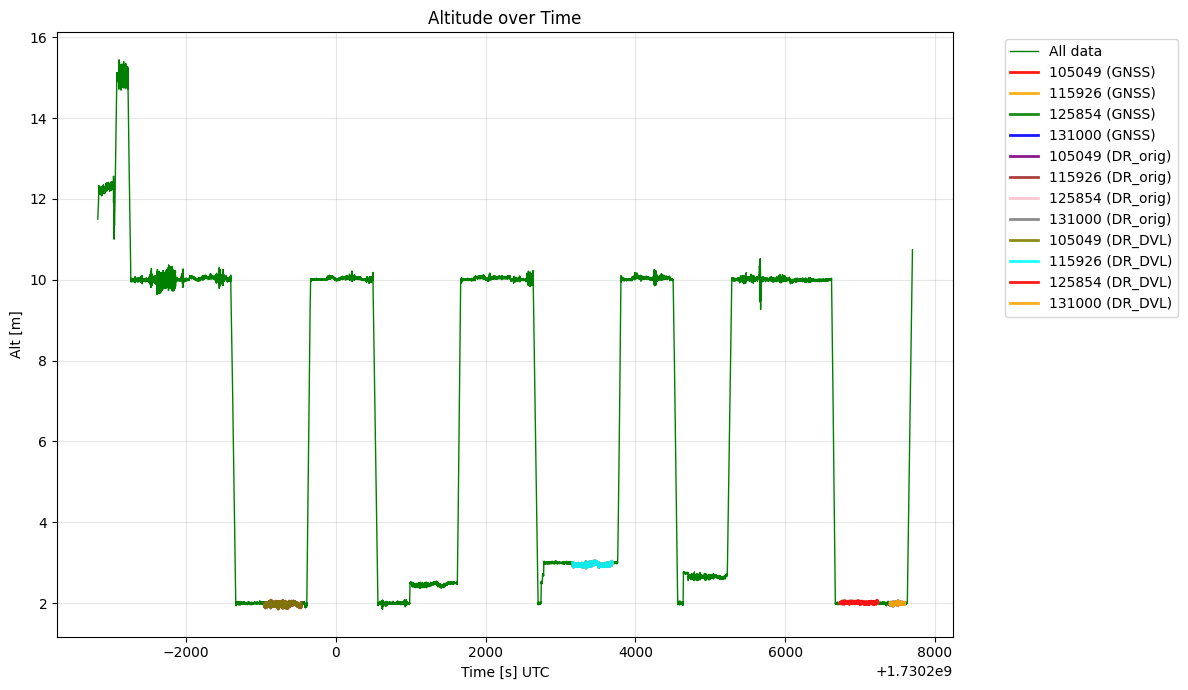

3D Plot: 232670 main points
X-axis range: -154.232646 to 48.373658
Y-axis range: -388.336934 to -307.957867
Depth range: 93.40 to 135.31


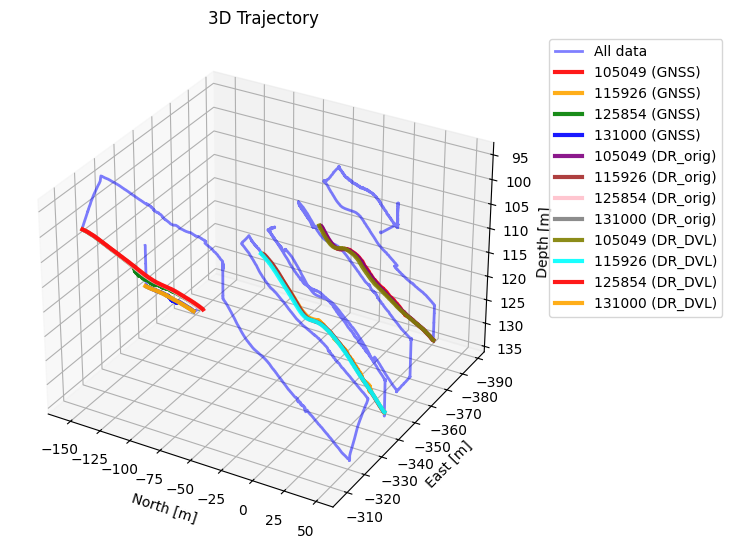

In [15]:
# 📊 COMPARISON: Plot All Three Approaches
print("\n📊 Now let's compare all three approaches:")
print("   🔵 Original: Simple extraction from main CSV (real GNSS positions)")
print("   🟠 _dr: Your original constant velocity dead reckoning")
print("   🟢 _dr_dvl_v2: New DVL velocity dead reckoning")
print()

# Combine all files for plotting
all_comparison_files = []

# Add original transects (real GNSS data)
all_comparison_files.extend(original_transect_files)

# Add your original DR files
all_comparison_files.extend(dr_files_original)

# Add new DVL DR files
all_comparison_files.extend(dr_files_dvl)

# Create meaningful labels
comparison_labels = []
transect_names = ["105049", "115926", "125854", "131000"]

for name in transect_names:
    comparison_labels.append(f"{name} (GNSS)")  # Real positions

for name in transect_names:
    comparison_labels.append(f"{name} (DR_orig)")  # Your original DR

for name in transect_names:
    comparison_labels.append(f"{name} (DR_DVL)")  # New DVL DR

# Filter to only existing files and matching labels
existing_files = []
existing_labels = []
for file_path, label in zip(all_comparison_files, comparison_labels):
    if os.path.exists(file_path):
        existing_files.append(file_path)
        existing_labels.append(label)
    else:
        print(f"⚠️  Missing: {label}")

print(f"\n🎯 Plotting {len(existing_files)} files for comparison...")

# Plot comparison with custom labels
if existing_files:
    # %matplotlib tk
    log_data.plot_with_transects(
        existing_files,
        transect_labels=existing_labels,
        use_meters=True,
        origin=origin_deg,
    )
else:
    print("❌ No files available for comparison!")

In [16]:
# 🔍 DETAILED ANALYSIS: Compare the Methods Quantitatively
print("\n🔍 Detailed comparison of dead reckoning accuracy...")
print(
    "   Comparing end positions: how close does each DR method get to real GNSS end position?"
)
print()

import pandas as pd
import numpy as np


def calculate_endpoint_error(original_csv, dr_csv, origin_deg):
    """Calculate how far the DR endpoint is from the real GNSS endpoint"""
    try:
        # Load both files
        df_orig = pd.read_csv(original_csv)
        df_dr = pd.read_csv(dr_csv)

        # Get final positions
        orig_lat, orig_lon = (
            df_orig["latitude [deg]"].iloc[-1],
            df_orig["longitude [deg]"].iloc[-1],
        )
        dr_lat, dr_lon = (
            df_dr["latitude [deg]"].iloc[-1],
            df_dr["longitude [deg]"].iloc[-1],
        )

        # Convert to meters for easier interpretation
        orig_east, orig_north = log_data.deg_to_meter_simple(
            [orig_lat], [orig_lon], origin=origin_deg
        )
        dr_east, dr_north = log_data.deg_to_meter_simple(
            [dr_lat], [dr_lon], origin=origin_deg
        )

        # Calculate distance error
        error_m = np.sqrt(
            (dr_east[0] - orig_east[0]) ** 2 + (dr_north[0] - orig_north[0]) ** 2
        )

        return error_m, (orig_east[0], orig_north[0]), (dr_east[0], dr_north[0])

    except Exception as e:
        print(f"Error calculating endpoint error: {e}")
        return None, None, None


# Compare each transect
transect_names = ["105049", "115926", "125854", "131000"]
print("📊 Endpoint accuracy comparison:")
print("   (How far does each DR method end up from the real GNSS endpoint?)")
print()

for i, name in enumerate(transect_names):
    orig_file = rf"E:\mjosa_new\navigation_data\{name}\nav_data_{name}.csv"
    dr_orig_file = rf"E:\mjosa_new\navigation_data\{name}\nav_data_{name}_dr.csv"
    dr_dvl_file = rf"E:\mjosa_new\navigation_data\{name}\nav_data_{name}_dr_dvl_v2.csv"

    print(f"🎯 Transect {name}:")

    if not os.path.exists(orig_file):
        print(f"   ❌ Original file missing")
        continue

    # Your original DR method
    if os.path.exists(dr_orig_file):
        error, real_pos, dr_pos = calculate_endpoint_error(
            orig_file, dr_orig_file, origin_deg
        )
        if error is not None:
            print(f"   🟠 Original DR error: {error:.1f} m")
        else:
            print(f"   🟠 Original DR: calculation failed")
    else:
        print(f"   🟠 Original DR file missing")

    # New DVL DR method
    if os.path.exists(dr_dvl_file):
        error, real_pos, dr_pos = calculate_endpoint_error(
            orig_file, dr_dvl_file, origin_deg
        )
        if error is not None:
            print(f"   🟢 DVL DR error: {error:.1f} m")

            # Load DVL stats
            df_dvl = pd.read_csv(dr_dvl_file)
            if "dvl_speed [m/s]" in df_dvl.columns:
                avg_speed = df_dvl["dvl_speed [m/s]"].mean()
                print(f"      📊 DVL avg speed: {avg_speed:.3f} m/s")
        else:
            print(f"   🟢 DVL DR: calculation failed")
    else:
        print(f"   🟢 DVL DR file missing - run the DVL creation cell above")

    print()

print("💡 Interpretation:")
print("   • Lower error = more accurate dead reckoning")
print(
    "   • DVL method should be more accurate if vehicle speed varied significantly from 0.2 m/s"
)
print("   • Your original method is proven and reliable - use it as the baseline!")


🔍 Detailed comparison of dead reckoning accuracy...
   Comparing end positions: how close does each DR method get to real GNSS end position?

📊 Endpoint accuracy comparison:
   (How far does each DR method end up from the real GNSS endpoint?)

🎯 Transect 105049:
   🟠 Original DR error: 0.0 m
   🟢 DVL DR error: 1.6 m
      📊 DVL avg speed: 0.197 m/s

🎯 Transect 115926:
   🟠 Original DR error: 0.0 m
   🟢 DVL DR error: 1.6 m
      📊 DVL avg speed: 0.199 m/s

🎯 Transect 125854:
   🟠 Original DR error: 0.0 m
   🟢 DVL DR error: 2.4 m
      📊 DVL avg speed: 0.202 m/s

🎯 Transect 131000:
   🟠 Original DR error: 0.0 m
   🟢 DVL DR error: 1.0 m
      📊 DVL avg speed: 0.200 m/s

💡 Interpretation:
   • Lower error = more accurate dead reckoning
   • DVL method should be more accurate if vehicle speed varied significantly from 0.2 m/s
   • Your original method is proven and reliable - use it as the baseline!


# merge into one file

In [17]:
import pandas as pd


def merge_transect_fixes(
    main_csv_path: str,
    transect_dr_paths: list[str],
    output_csv_path: str,
    timestamp_col: str = "timestamp [unix epoch s]",
):
    """
    Merge a main navigation CSV with one or more "dead-reckoned" transect CSVs.
    Wherever a transect CSV has the same timestamp as the main file, its row
    replaces the main one.

    :param main_csv_path:      Path to the original full-track CSV.
    :param transect_dr_paths:  List of paths to the corrected "_dr.csv" transect files.
    :param output_csv_path:    Where to write the merged result.
    :param timestamp_col:      Name of the timestamp column (default "timestamp [unix epoch s]").
    """
    # 1) Load main track
    main_df = pd.read_csv(main_csv_path)
    if timestamp_col not in main_df.columns:
        raise KeyError(
            f"Timestamp column '{timestamp_col}' not found in {main_csv_path!r}"
        )

    # 2) For each corrected transect: drop overlapping rows, then append
    for dr_path in transect_dr_paths:
        dr_df = pd.read_csv(dr_path)
        if timestamp_col not in dr_df.columns:
            raise KeyError(
                f"Timestamp column '{timestamp_col}' not found in {dr_path!r}"
            )

        # remove any rows in main_df that share timestamps with dr_df
        ts_to_replace = set(dr_df[timestamp_col])
        main_df = main_df[~main_df[timestamp_col].isin(ts_to_replace)]

        # append the corrected transect rows
        main_df = pd.concat([main_df, dr_df], ignore_index=True)

    # 3) sort by timestamp and write out
    main_df.sort_values(by=timestamp_col, inplace=True)
    main_df.to_csv(output_csv_path, index=False)
    print(f"Merged CSV written to: {output_csv_path}")

In [18]:
main_csv = r"E:\mjosa_new\navigation_data\nav_data_from_logfile.csv"
transect_dr = [
    r"E:\mjosa_new\navigation_data\105049\nav_data_105049_dr.csv",
    r"E:\mjosa_new\navigation_data\115926\nav_data_115926_dr.csv",
    r"E:\mjosa_new\navigation_data\125854\nav_data_125854_dr.csv",
    r"E:\mjosa_new\navigation_data\131000\nav_data_131000_dr.csv",
]
output_csv = r"E:\mjosa_new\navigation_data\nav_data_merged.csv"

merge_transect_fixes(main_csv, transect_dr, output_csv)

Merged CSV written to: E:\mjosa_new\navigation_data\nav_data_merged.csv


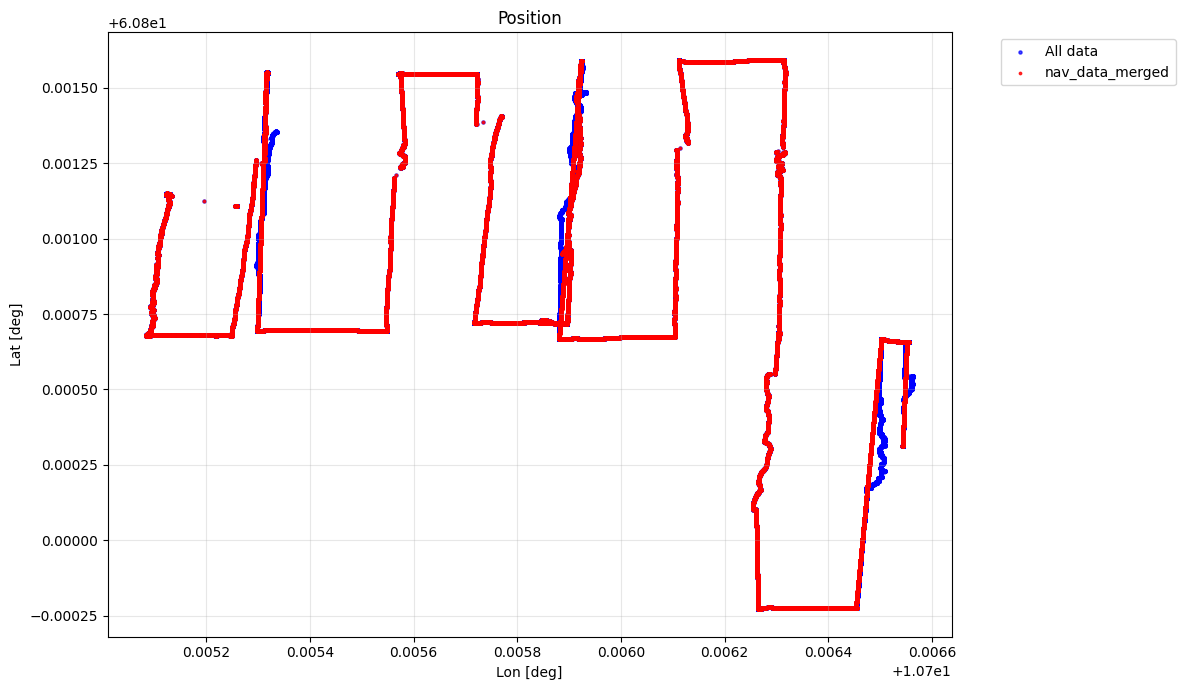

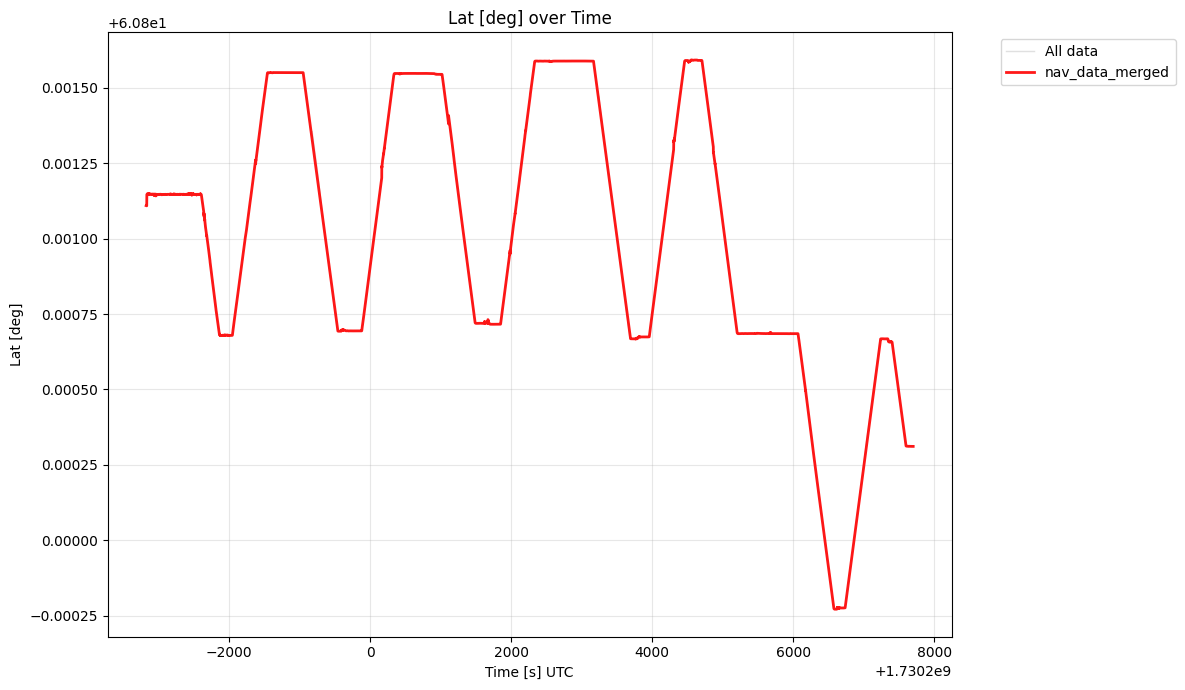

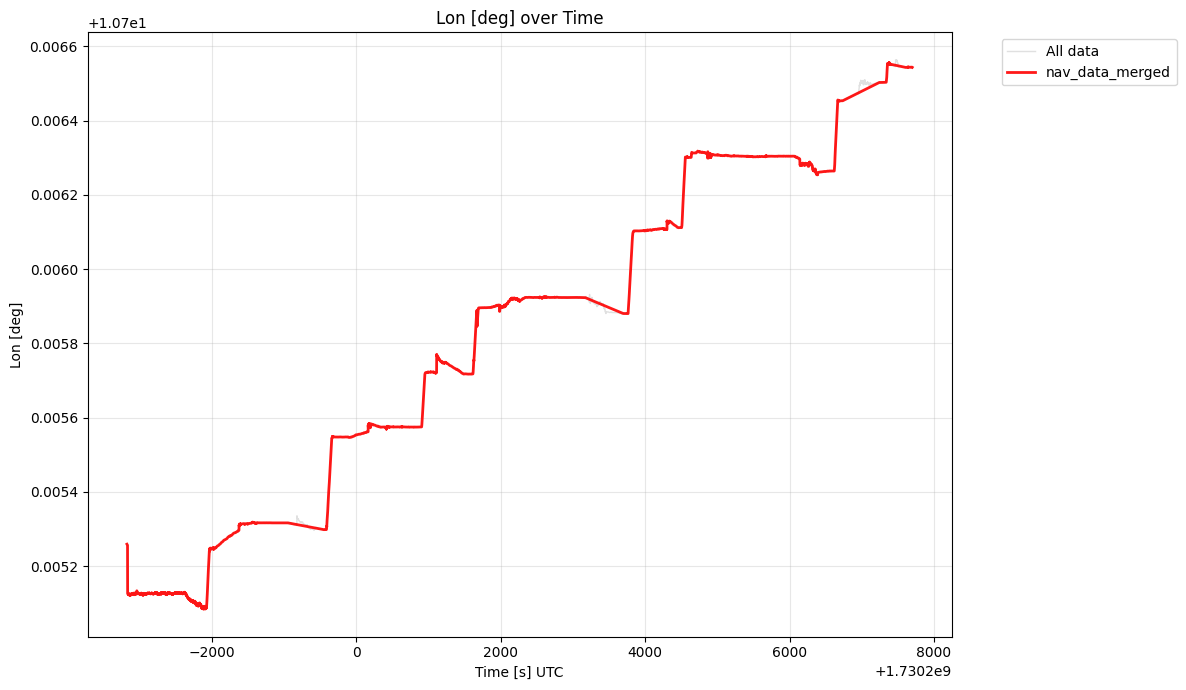

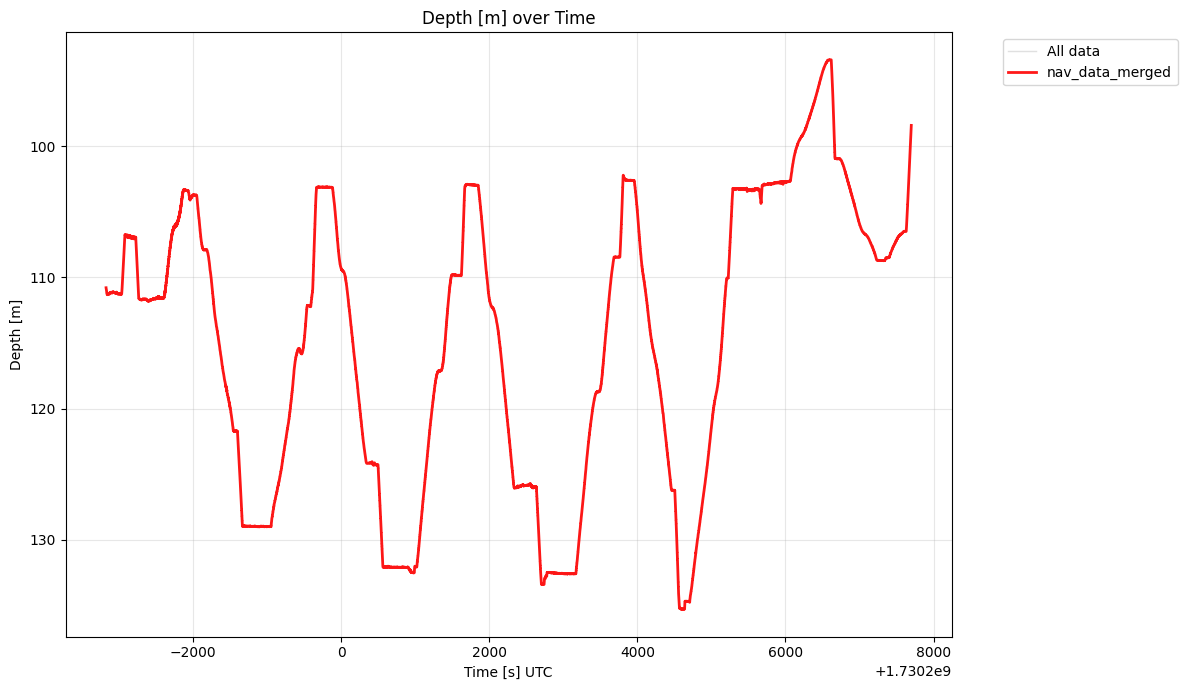

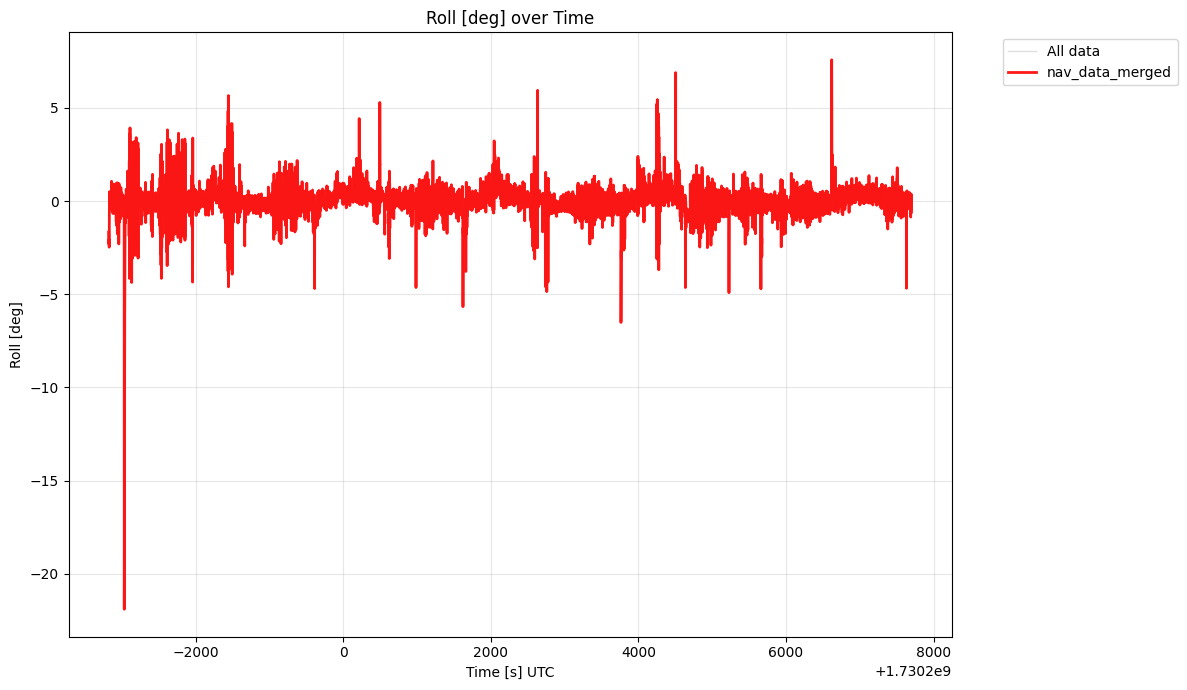

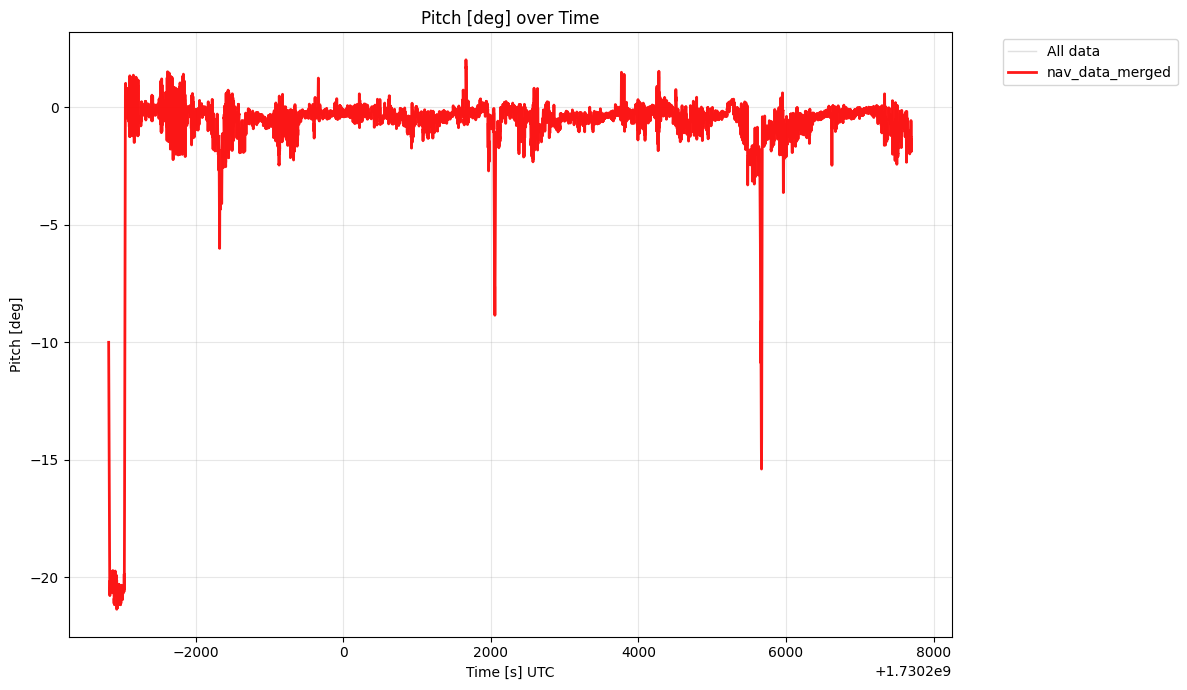

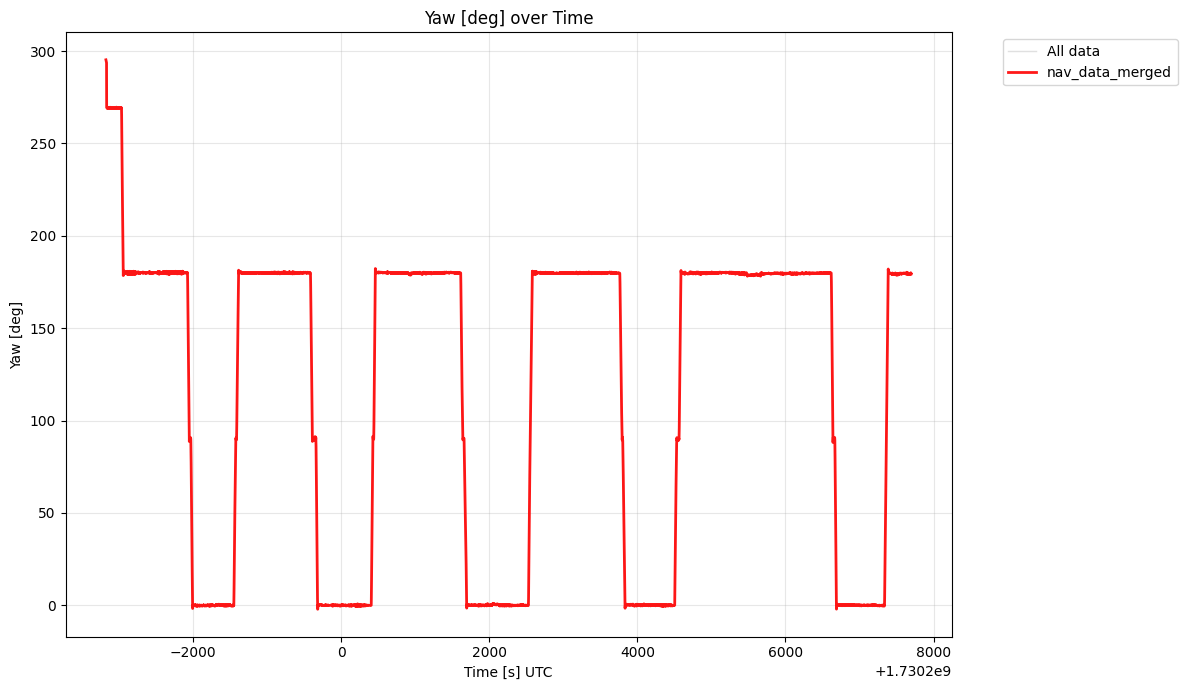

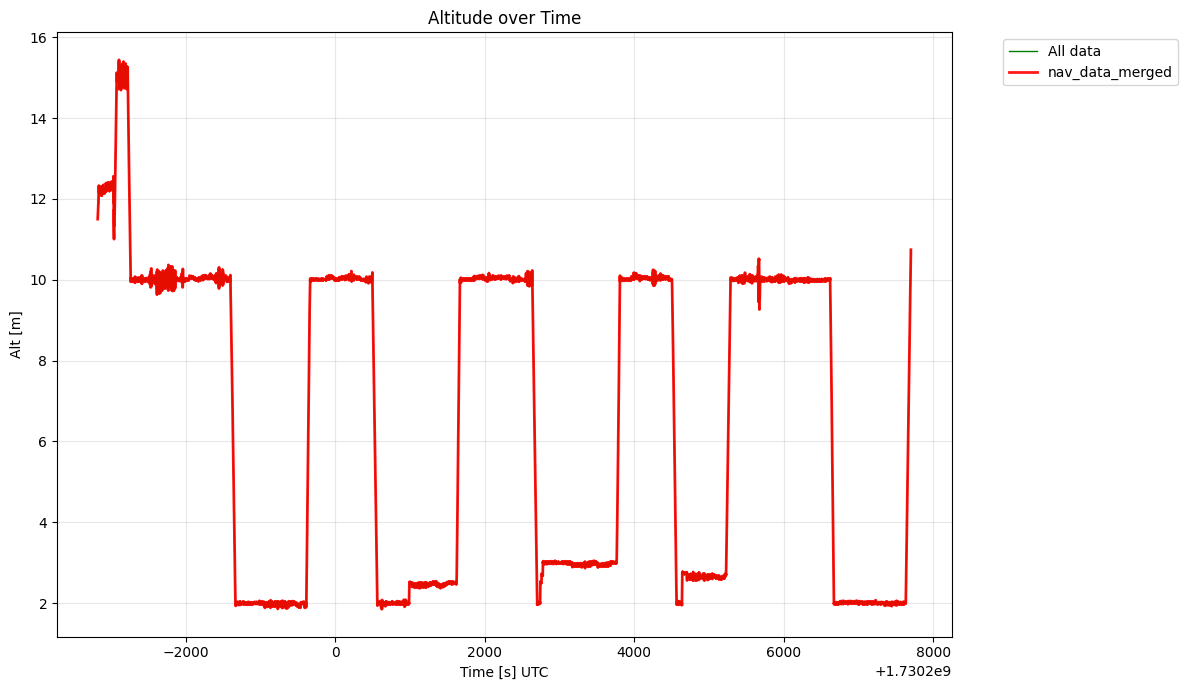

3D Plot: 232670 main points
X-axis range: 60.799772 to 60.801592
Y-axis range: 10.705084 to 10.706564
Depth range: 93.40 to 135.31


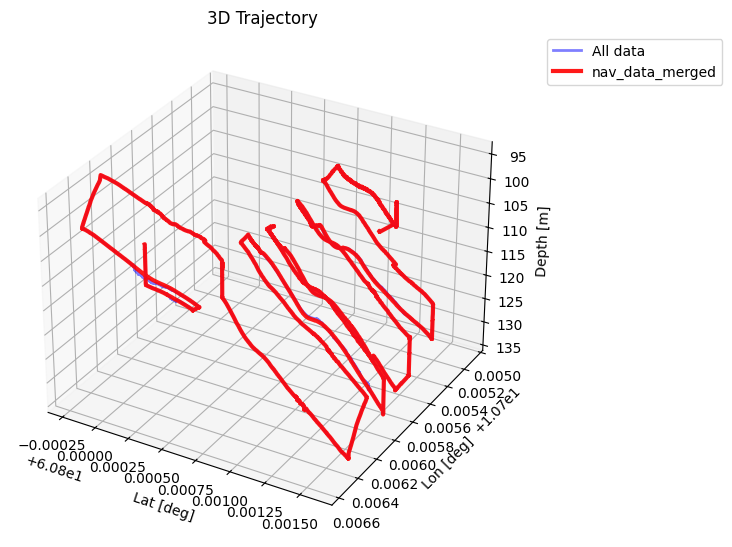

In [19]:
# 1. Load your main navigation data
main_csv = r"E:\mjosa_new\navigation_data\nav_data_from_logfile.csv"
log_data = LogData(main_csv)

# 2. List your transect CSV files
transect_files = [r"E:\mjosa_new\navigation_data\nav_data_merged.csv"]
# %matplotlib tk

log_data.plot_with_transects(transect_files)

# create new .txt for EIVA to resample track

In [20]:
def convert_nav_data_to_txt_exact(csv_path, output_path="navigation_output.txt"):
    """
    Convert navigation CSV data to formatted txt file with exact format matching.

    Parameters:
    csv_path (str): Path to input CSV file
    output_path (str): Path for output txt file (default: 'navigation_output.txt')

    Returns:
    int: Number of data points processed
    """
    import pandas as pd
    from datetime import datetime

    try:
        # Read the CSV file
        df = pd.read_csv(csv_path)

        # Convert unix timestamp to datetime
        df["datetime"] = pd.to_datetime(df["timestamp [unix epoch s]"], unit="s")

        # Format the output lines
        output_lines = []

        # Header with exact spacing
        header = (
            "Date     Time          Lat [deg]         Long [deg]        Depth [Meter]"
        )
        output_lines.append(header)

        for _, row in df.iterrows():
            # Format each component exactly as specified
            date_str = row["datetime"].strftime("%Y%m%d")  # YYYYMMDD
            time_str = row["datetime"].strftime("%H%M%S.%f")  # HHMMSS.ssssss

            # Format coordinates with appropriate precision
            lat_str = f"{row['latitude [deg]']:.14f}"
            lon_str = f"{row['longitude [deg]']:.14f}"
            depth_str = f"{row['depth [m]']:.10f}"

            # Single space separation as in your example
            line = f"{date_str} {time_str} {lat_str} {lon_str} {depth_str}"
            output_lines.append(line)

        # Write to txt file
        with open(output_path, "w") as f:
            for line in output_lines:
                f.write(line + "\n")

        print(f"File created successfully: {output_path}")
        print(f"Processed {len(df)} data points")
        print("\nActual output format:")
        for i, line in enumerate(output_lines[:4]):
            print(f"'{line}'")

        return len(df)

    except Exception as e:
        print(f"Error processing file: {e}")
        return 0

In [21]:
data_points = convert_nav_data_to_txt_exact(
    csv_path=r"E:\mjosa_new\navigation_data\nav_data_merged.csv",
    output_path=r"E:\mjosa_new\navigation_data\merged_data_for_EIVA.txt",
)

File created successfully: E:\mjosa_new\navigation_data\merged_data_for_EIVA.txt
Processed 232670 data points

Actual output format:
'Date     Time          Lat [deg]         Long [deg]        Depth [Meter]'
'20241029 101342.842664 60.80110898827765 10.70525895701778 110.7889106455'
'20241029 101342.866320 60.80110898648739 10.70525895053506 110.7889173162'
'20241029 101342.893757 60.80110898441102 10.70525894301639 110.7944052777'


In [22]:
def plot_navigation_txt_3d(
    txt_file_path,
    output_filename="navigation_3d_plot.png",
    sample_every=1,
    color_by_depth=True,
):
    """
    Plot navigation data from txt file in 3D.

    Parameters:
    txt_file_path (str): Path to the navigation txt file
    output_filename (str): Name for saved plot image
    sample_every (int): Plot every nth point (for performance with large datasets)
    color_by_depth (bool): Color points by depth values

    Returns:
    matplotlib figure object
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D

    # Read the txt file, skip header row
    df = pd.read_csv(
        txt_file_path,
        sep=" ",
        skiprows=1,
        header=None,
        names=["Date", "Time", "Lat", "Lon", "Depth"],
    )

    # Sample data for performance if dataset is large
    if sample_every > 1:
        df = df.iloc[::sample_every]

    # Extract coordinates
    lat = df["Lat"].values
    lon = df["Lon"].values
    depth = -df["Depth"].values  # Negative for proper depth visualization

    # Create 3D plot
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection="3d")

    # Color mapping
    if color_by_depth:
        scatter = ax.scatter(
            lon, lat, depth, c=df["Depth"], cmap="viridis_r", s=1, alpha=0.7
        )
        plt.colorbar(scatter, ax=ax, label="Depth (m)", shrink=0.5)
    else:
        ax.scatter(lon, lat, depth, c="blue", s=1, alpha=0.7)

    # Labels and title
    ax.set_xlabel("Longitude (deg)")
    ax.set_ylabel("Latitude (deg)")
    ax.set_zlabel("Depth (m)")
    ax.set_title(f"Navigation Track 3D Visualization\n{len(df)} data points")

    # Add grid
    ax.grid(True, alpha=0.3)

    # Set viewing angle for better perspective
    ax.view_init(elev=20, azim=45)

    # Add statistics text
    stats_text = f"""Data Statistics:
    Points: {len(df):,}
    Lat range: {lat.min():.6f} to {lat.max():.6f}
    Lon range: {lon.min():.6f} to {lon.max():.6f}  
    Depth range: {df['Depth'].min():.1f} to {df['Depth'].max():.1f} m"""

    ax.text2D(
        0.02,
        0.98,
        stats_text,
        transform=ax.transAxes,
        verticalalignment="top",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
    )

    plt.tight_layout()
    plt.savefig(output_filename, dpi=300, bbox_inches="tight")
    print(f"3D plot saved as: {output_filename}")
    print(f"Plotted {len(df):,} navigation points")

    plt.show()
    return fig


# Safe wrapper with error handling
def plot_nav_txt_safe(txt_path):
    """
    Safe wrapper function with error handling.
    """
    try:
        # For large files, sample every 10th point for performance
        fig = plot_navigation_txt_3d(txt_path, sample_every=10)
        return fig
    except FileNotFoundError:
        print(f"File not found: {txt_path}")
        print("Make sure the file path is correct!")
    except Exception as e:
        print(f"Error plotting data: {e}")
        print("Check that your txt file has the correct format!")

3D plot saved as: navigation_3d_plot.png
Plotted 232,670 navigation points


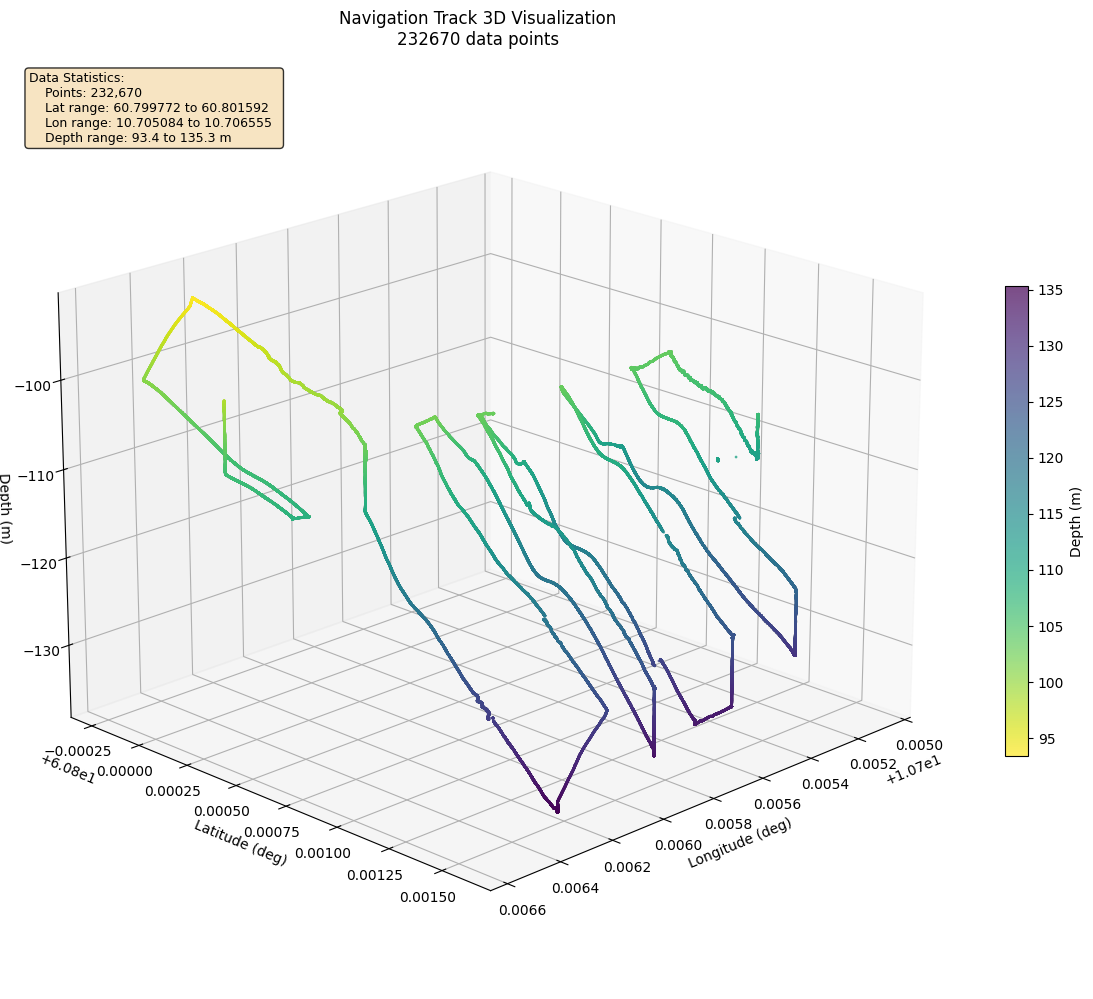

In [23]:
output_path = r"E:\mjosa_new\navigation_data\merged_data_for_EIVA.txt"

fig = plot_navigation_txt_3d(output_path)

# DVL data

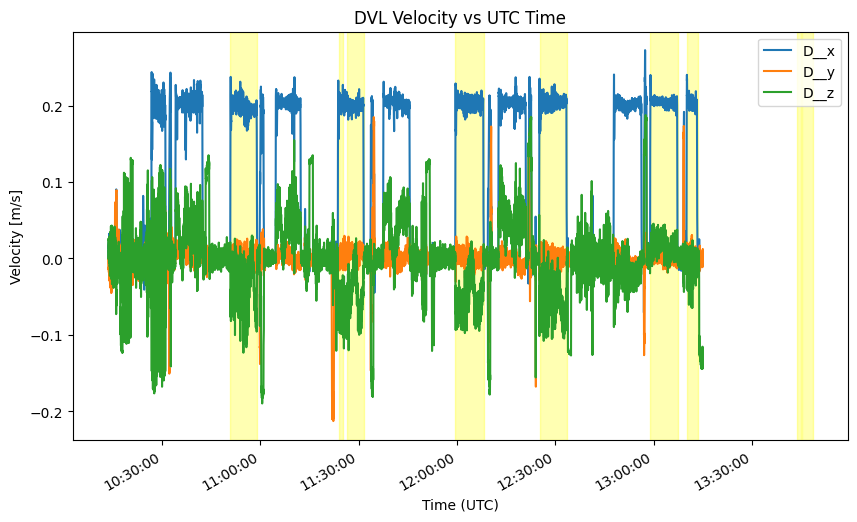

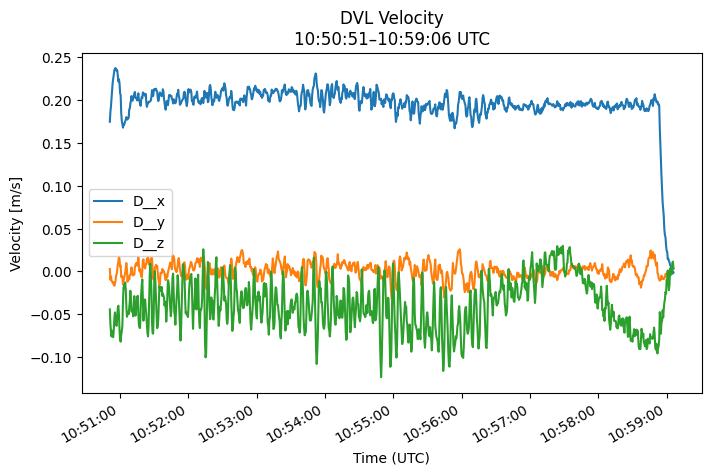

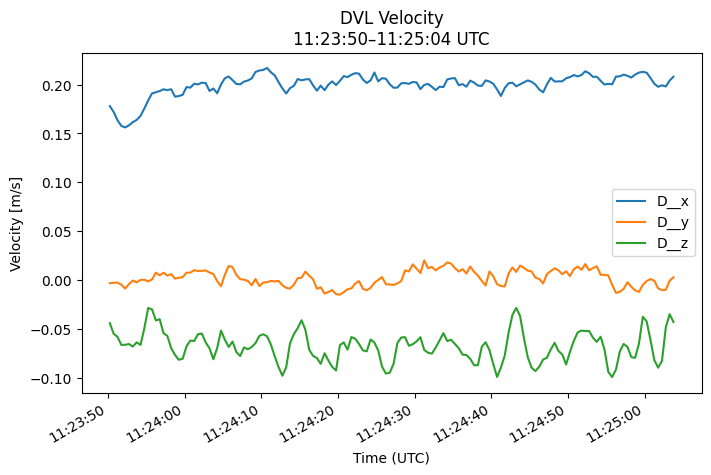

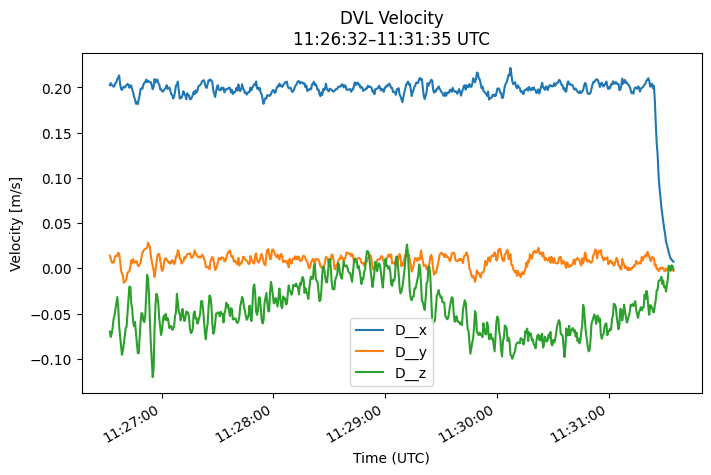

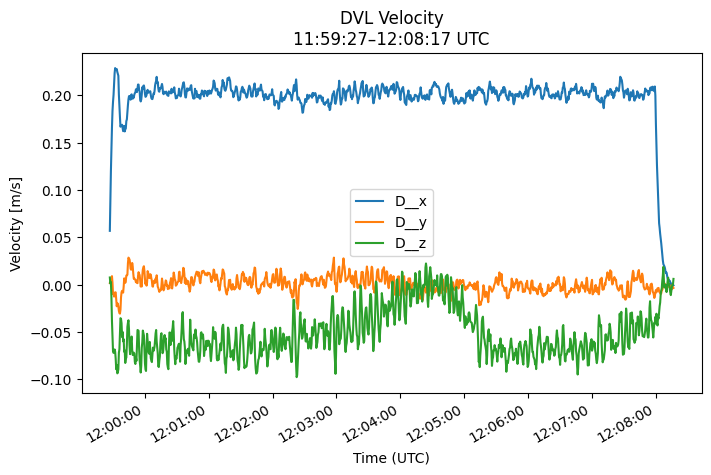

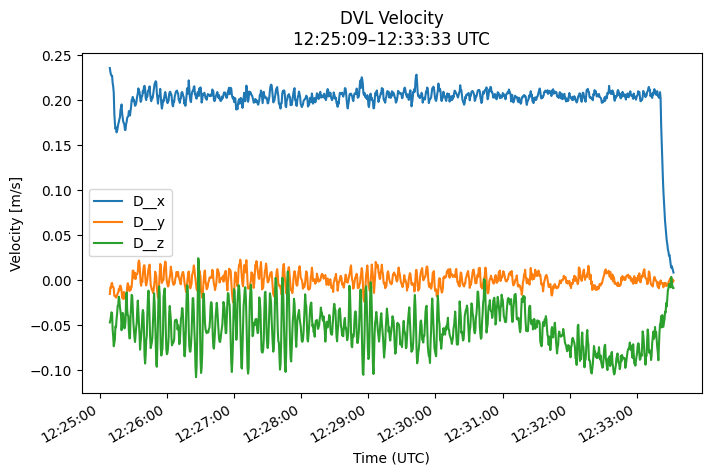

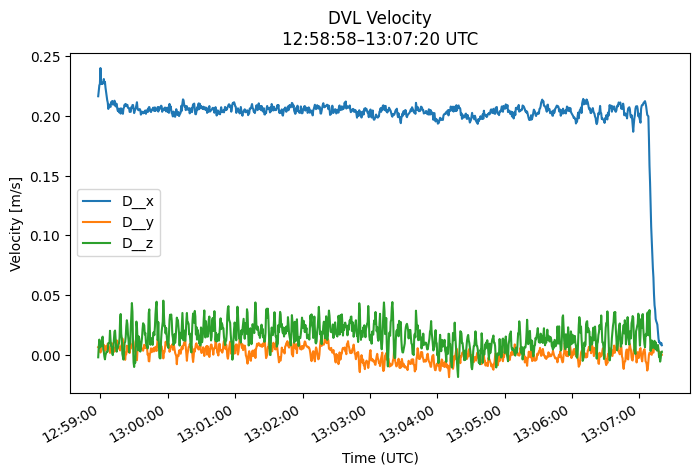

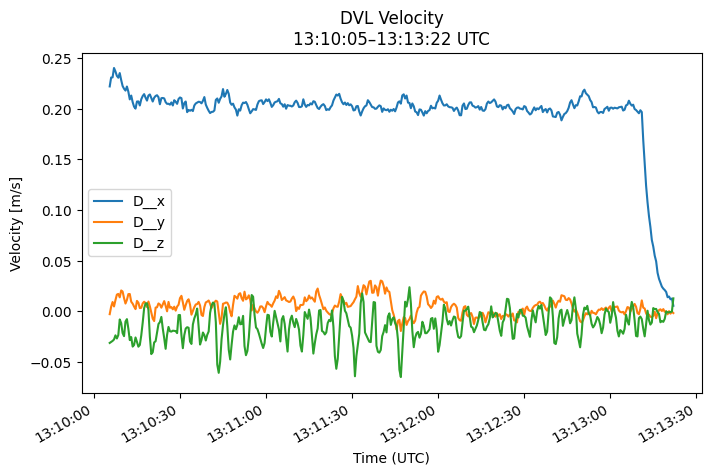

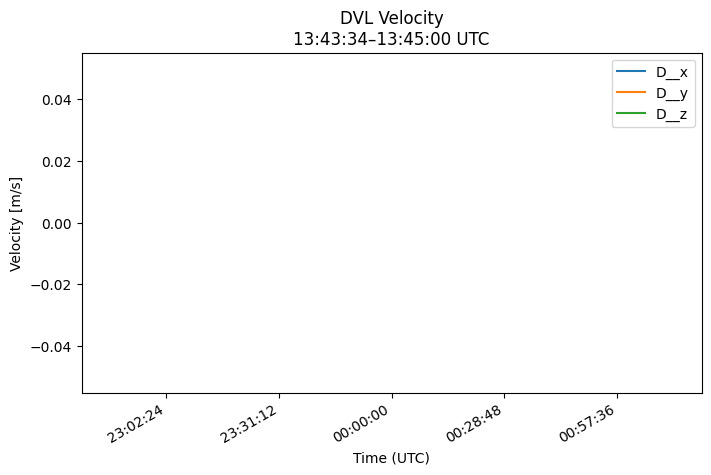

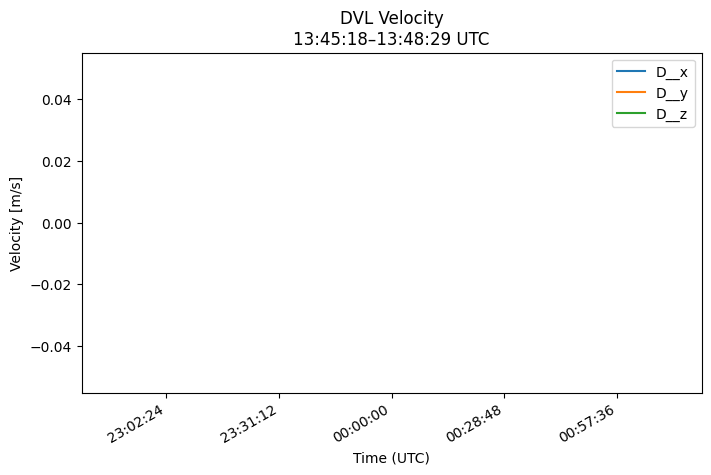

In [24]:
analyzer.plot_dvl_velocity(highlight_intervals=imu_transects)
analyzer.plot_dvl_velocity_intervals(imu_transects)